# Development notebook

This is a folder for notes and files that I'm using for development.  
This won't be published with the final package.

## General notes

### Running Part 1:
```sh
snakemake --dag get_input_for_minknow | dot -Tsvg > dag.get_input_for_minknow.20251002.svg
snakemake get_input_for_minknow --use-conda
```

### Future things to look into

* Translating wf-variation to work inside/with dockerised version of Panorama

# Diary

## Thu 2 Oct 2025

Testing Part 1: Adaptive Sequencing Target File Creation.  

In tmux window called "pano".  
Directory to work in: `/external/analyses/lucy/nanopore_multiBM_pipeline`  
conda environment: `bm_min_venv`

In [ ]:
snakemake --dag get_input_for_minknow | dot -Tsvg > dag.get_input_for_minknow.20251002.svg
snakemake get_input_for_minknow --use-conda

## Fri 3 Oct 2025

**Continuing to debug `get_input_for_minknow`**  

Fixed make_panel_bed > restructure_to_bed to hopefully make more robust to panel input and python version changes.

Next problem:

```error
MissingOutputException in rule run_make_adaptive_ref in file /external/analyses/lucy/nanopore_multiBM_pipeline/workflow/rules/panel_prep.smk, line 40:
Job 2  completed successfully, but some output files are missing. Missing files after 5 seconds. This might be due to filesystem latency. If that is the case, consider to increase the wait time with --latency-wait:
results/20241002_BCG_on_NMIBC/minknow_input_supp/targets.minknow.2000.bed (missing locally, parent dir contents: biomarker_panel.bed, sorted_all_targets.2000.bed, ini_all_targets.2000.bed)
results/20241002_BCG_on_NMIBC/minknow_input_supp/targets.minknow.2000.fasta (missing locally, parent dir contents: biomarker_panel.bed, sorted_all_targets.2000.bed, ini_all_targets.2000.bed)
```

Don't know what the problem was really, but I uncommented some stuff and it worked!  
Tidied up a bit and committed.

Now begin working on Part 2.  

In [ ]:
snakemake --dag run_sample_panel_for_BM_classifier | dot -Tsvg > dag.run_sample_panel_for_BM_classifier.20251003.svg
snakemake run_sample_panel_for_BM_classifier --use-conda

Results:  

[Fri Oct  3 16:42:58 2025]
localrule combine_bedmethyls:
    input: results/20241002_BCG_on_NMIBC/test1/wf-humvar/test1.wf_mods.1.bedmethyl.gz, results/20241002_BCG_on_NMIBC/test1/wf-humvar/test1.wf_mods.2.bedmethyl.gz, results/20241002_BCG_on_NMIBC/test1/wf-humvar/test1.wf_mods.ungrouped.bedmethyl.gz
    output: results/20241002_BCG_on_NMIBC/test1/mod_calling/test1.wf_mods.all.bedmethyl.bed
    jobid: 10
    benchmark: logs/20241002_BCG_on_NMIBC/test1/test1.benchmark.combine_bedmethyls.tsv
    reason: Missing output files: results/20241002_BCG_on_NMIBC/test1/mod_calling/test1.wf_mods.all.bedmethyl.bed; Input files updated by another job: results/20241002_BCG_on_NMIBC/test1/wf-humvar/test1.wf_mods.ungrouped.bedmethyl.gz, results/20241002_BCG_on_NMIBC/test1/wf-humvar/test1.wf_mods.1.bedmethyl.gz, results/20241002_BCG_on_NMIBC/test1/wf-humvar/test1.wf_mods.2.bedmethyl.gz
    resources: tmpdir=/tmp

bgzip: invalid option -- 'k'

Version: 1.10.2-3ubuntu0.1
Usage:   bgzip [OPTIONS] [FILE] ...
Options:
   -b, --offset INT           decompress at virtual file pointer (0-based uncompressed offset)
   -c, --stdout               write on standard output, keep original files unchanged
   -d, --decompress           decompress
   -f, --force                overwrite files without asking
   -h, --help                 give this help
   -i, --index                compress and create BGZF index
   -I, --index-name FILE      name of BGZF index file [file.gz.gzi]
   -l, --compress-level INT   Compression level to use when compressing; 0 to 9, or -1 for default [-1]
   -r, --reindex              (re)index compressed file
   -g, --rebgzip              use an index file to bgzip a file
   -s, --size INT             decompress INT bytes (uncompressed size)
   -@, --threads INT          number of compression threads to use [1]
   -t, --test                 test integrity of compressed file
[Fri Oct  3 16:42:58 2025]
Error in rule bgzip_clinvar_vcf:
    jobid: 3
    input: results/20241002_BCG_on_NMIBC/test1/wf-humvar/test1.wf_snp_clinvar.vcf
    output: results/20241002_BCG_on_NMIBC/test1/wf-humvar/test1.wf_snp_clinvar.vcf.gz
    shell:
        bgzip -k results/20241002_BCG_on_NMIBC/test1/wf-humvar/test1.wf_snp_clinvar.vcf
        (one of the commands exited with non-zero exit code; note that snakemake uses bash strict mode!)

[Fri Oct  3 16:42:58 2025]
Finished job 10.
2 of 14 steps (14%) done
Shutting down, this might take some time.
Exiting because a job execution failed. Look above for error message
Complete log: .snakemake/log/2025-10-03T123616.932506.snakemake.log
WorkflowError:
At least one job did not complete successfully.

### Thu 06 Nov 2025

To run:  
`mamba activate bm_min_venv`
`cd /external/analyses/lucy/nanopore_multiBM_pipeline`  
`snakemake run_sample_panel_for_BM_classifier --use-conda`  

note that some stuff is breaking maybe because I have it set up for all the data specifically, which shouldn't happen. 
- I have so many more variants found in old workflows than in this one.
- Shouldn't break because of set data, the whole point is that it's able to go on lots of data!
- getting this error:
  - in vcf but not found yet: (entry 61 details from panel) 
  - except the details its giving are from 064
- Also the "index is older than the vcf" file
- Maybe need to do a fresh run?

### Mon 10 Nov 2025

Do a fresh run today.  

mamba activate bm_min_venv  
cd /external/analyses/lucy/nanopore_multiBM_pipeline  

Test2 has the following config:

```
project_name: "20241002_BCG_on_NMIBC"
sample: "test2"
panel_metadata: "config/panel_metadata.csv"
bam_pass_directory: "/mnt/uow-pathology-dun/hans_external/data/lucy/panorama/20241107-BiomarkerProject/merged_bams"

buffersize_bp: 2000
min_genome_coverage: 0.5
max_genome_coverage: 2.0
max_cores: 4

nextflow:
  basecaller: "dna_r10.4.1_e8.2_400bps_hac@v4.1.0"
  profile: "standard"
  threads: 4

cibersortx:
  username: lucy.picard@postgrad.otago.ac.nz
  token: 62c6ce7d617349ca44a7ee8efb7df65c
```
This is the same as test1. Except for the lower number of cores used to account for the bebic basecalling run  
Ergh it failed anyway.  

### Tue 11 Nov 2025

Fixed entry 064 on the panel, as it was supposed to be a snv but had ~4000 bp in it instead. Hunted down the rs ID - having the reference available is great!  

Working through errors in the snv code  

Reached methylCS

### Mon 24 Nov 2025 - cont on TheGreatHall

Ask ai how much data a prom run should generate.


In nanopore sequencing, how much data, in nucleotide bases, gigabytes, and read depth, should a 24 hour run on a promethion flow cell get under these conditions:
- DNA extraction from tissue sample using the qiagen DNeasy extraction kit
- rapid barcoding kit
- adaptive sequencing for 5% of the human genome

I just need a ballpark idea. And I use bam files, not fastq. Gigabytes should be measured using pod5s.
___

ANSWER:  

Here’s a ballpark estimate for a 24-hour PromethION run under your exact conditions, using POD5 and BAM as the reference formats:

✅ 1. Total Bases

A PromethION flow cell typically yields 80–150 Gbases in 24 hours under ideal conditions.  
With rapid barcoding kit (slightly lower throughput) and adaptive sequencing rejecting ~95% of reads, expect 40–80 Gbases total.  


✅ 2. POD5 File Size

POD5 stores raw signal data, which is much larger than FASTQ/BAM.  
Rough rule: ~2–3 GB per Gb of basecalled data (varies by read length and sampling rate).  
For 40–80 Gbases, POD5 size ≈ 80–240 GB (often closer to 2.5× base count).


✅ 3. BAM File Size

BAM is compressed alignment data. Typical ratio ≈ 0.8–1.2 bytes per base.  
For 40–80 Gbases, BAM size ≈ 35–90 GB.  


✅ 4. Read Depth

Human genome ≈ 3.2 Gb.  
Whole genome coverage:

40 Gbases → ~12×
80 Gbases → ~25×


Target 5% (≈160 Mb):

If enrichment works well, coverage could easily exceed 500×–1000×.

*Summary Table*

| Metric | Estimate (24h run) | 
| --- | --- |
| Bases | 40–80 Gbases | 
| POD5 size | 80–240 GB |
| BAM size | 35–90 GB | 
| Whole-genome depth | ~12–25× |
| Target (5%) depth | 500×+ (variable) |

___
FOLLOW UP
estimating number of reads and N50 read length distribution is desired yes, however can you also check this against real-world data?

ANSWER - based on Native Barcoding Kit

📊 Total Yield & Read Count  

Total bases: Expect 40–80 Gbases, accounting for rapid prep and adaptive filtering. [nanoporetech.com], [nanoporetech.com]  
Read count: With typical read lengths of 10–20 kb, that yields approximately 2–8 million reads (e.g., 40 Gb / 20 kb = 2 M; 80 Gb / 10 kb = 8 M).  


📈 Read Length & N50  

Real-world runs report N50s around 8 kb for adaptive sampling on PromethION targeting human gene panels. [a.storyblok.com]  
For whole-genome runs from tissue DNA, expect N50 between 15–25 kb; adaptive sampling may reduce long-read yield, so estimate N50: ~10–15 kb.


💾 POD5 and BAM File Sizes  

POD5 size: About 2–3 GB per Gb basecalled.  

For 40 Gb → ~80–120 GB;  
for 80 Gb → ~160–240 GB.  
[nanoporetech.com], [biomolecul...ystems.com]


BAM size: ~0.8–1.2 bytes per base.  

For 40–80 Gb, expect ~35–90 GB of aligned BAM data.  
[nanoporetech.com], [nanoporetech.com]


🎯 Coverage Depth

Whole-genome coverage:  

40 Gb → ~12×; 80 Gb → ~25×.


For your 5% target (~160 Mb):

Adaptive enrichment generally produces 6–7× fold enrichment in real gene panel data (e.g., pharmacogenes). [a.storyblok.com]  
That gives on-target yield ~2.5–5 Gb → 15,000×–30,000× coverage.  
Yield varies by enrichment stringency; conservative ballpark: hundreds to thousands ×, but real runs exceed 10,000× for small panels.


✅ Real-World Adaptive Sampling Example  
From a pharmacogenomics experiment (5 samples multiplexed on a PromethION 2 Solo):  

Total yield per flow cell: ~20–21 Gb.  
On-target yield: ~2.6–3 Gb → ~60× coverage across pharmacogenes.  
On-target read N50: ~8 kb.  
[a.storyblok.com]  

Scaling to a single sample and higher throughput:  

Total 40–80 Gb,  
On-target bases: 4–8 Gb (at 5% target),  
On-target coverage: ~25 000–50 000×.  


⚙️ Estimated Summary Table

| Metric | Estimate | 
| --- | --- |
| Total bases | 40–80 Gb | 
| Read count | 2–8 million reads | 
| N50 read length | ~10–15 kb | 
| POD5 size | 80–240 GB | 
| BAM size | 35–90 GB | 
| Whole-genome coverage | 12×–25× | 
| Target (5%) coverage | hundreds to >10,000× |

___
MinION similarities


| Metric                | Estimate            |
|-----------------------|---------------------|
| Total bases           | 8–12 Gb            |
| Reads                 | ~1.0–1.5 million   |
| N50 read length       | ~5–10 kb           |
| POD5 size             | ~16–36 GB          |
| BAM size              | ~6–14 GB           |
| Whole-genome coverage | ~2.5–4×            |
| 5% target coverage    | ~25–35×            |

___
Comparison table  



| Metric                | MinION (Adaptive, Rapid Kit) | PromethION (Adaptive, Rapid Kit, 1 sample) | PromethION (Adaptive, Rapid Kit, 5 samples)    |
|-----------------------|------------------------------|--------------------------------------------|------------------------------------------------|
| Total bases           | 8–12 Gb                      | 40–80 Gb                                   | 8–16 Gb per sample                             |
| Reads                 | ~1.0–1.5 million             | ~3.5–7 million                             | ~0.67–1.33 million per sample                  |
| N50 read length       | ~5–10 kb                     | ~10–15 kb                                  | ~10–15 kb                                      |
| POD5 size             | ~16–36 GB                    | ~80–240 GB                                 | ~80–240 GB total                               |
| BAM size              | ~6–14 GB                     | ~35–90 GB                                  | ~35–90 GB total                                |
| Whole-genome coverage | ~2.5–4×                      | ~12–25×                                    | ~2.5–5× per sample                             |
| 5% target coverage    | ~25–35×                      | hundreds to >10,000×                       | tens to hundreds × per sample                  |
| Typical run duration  | ~24 h                        | ~24 h                                      | ~24 h                                          |
| Estimated reagent cost| US$500–700                   | US$1,500–2,000 (US$1,795 for Native Kit)   | US$1,500–2,000 total (US$1,795 for Native Kit) |
| Cost per sample       | —                            | —                                          | US$300–400 per sample (US$359 for Native Kit)  |




## Tue 3 March 2026

Moved to working on Aoraki.  

In [ ]:
# tmux window "panorama"
cd /home/dejlu44p/Projects/Panorama/nanopore_multiBM_pipeline
conda create -n pano_snk -c conda-forge -c bioconda snakemake
# python v3.13.12
# snakemake v9.16.3

In [ ]:
The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    libgcc-15.2.0              |      he0feb66_18        1017 KB  conda-forge
    libgomp-15.2.0             |      he0feb66_18         589 KB  conda-forge
    libstdcxx-15.2.0           |      h934c35e_18         5.6 MB  conda-forge
    markupsafe-3.0.3           |  py313h3dea7bd_1          25 KB  conda-forge
    numpy-2.4.2                |  py313hf6604e3_1         8.4 MB  conda-forge
    platformdirs-4.9.2         |     pyhcf101f3_0          25 KB  conda-forge
    python-3.13.12             |hc97d973_100_cp313        35.6 MB  conda-forge
    rich-14.3.3                |     pyhcf101f3_0         204 KB  conda-forge
    slack-sdk-3.40.1           |     pyhd8ed1ab_0         157 KB  conda-forge
    slack_sdk-3.40.1           |       hd8ed1ab_0           7 KB  conda-forge
    smart_open-7.5.1           |     pyhcf101f3_0          55 KB  conda-forge
    snakemake-9.16.3           |       hdfd78af_0          10 KB  bioconda
    snakemake-interface-storage-plugins-4.3.3|     pyh84498cf_0          22 KB  bioconda
    snakemake-minimal-9.16.3   |     pyhdfd78af_0         854 KB  bioconda
    typer-0.24.0               |     pyhcf101f3_0         115 KB  conda-forge
    ubiquerg-0.9.1             |     pyhd8ed1ab_0          23 KB  conda-forge
    ------------------------------------------------------------
                                           Total:        53.0 MB

In [ ]:
conda activate pano_snk

snakemake run_sample_panel_for_BM_classifier --dag | dot -Tsvg > dag.run_sample_panel_for_BM_classifier.20260303.svg
snakemake run_sample_panel_for_BM_classifier -n --use-conda

srun --partition=aoraki --ntasks=1 --cpus-per-task=8 --mem=16G --time=4:00:00 --pty bash -i
conda activate pano_snk
snakemake run_sample_panel_for_BM_classifier --use-conda --cores 'all'

conda env for methylcibersort is not being made. Figure it out manually

In [ ]:
conda create -n mCS_building_venv
conda activate mCS_building_venv
conda install -c conda-forge r-base=3.6.3
conda install -c conda-forge -c bioconda r-quadprog r-matrixstats
conda install -c conda-forge -c bioconda r-nmf
conda install -c conda-forge -c bioconda r-doparallel r-glmnet r-caret
conda install -c conda-forge -c bioconda bioconductor-multtest
conda install -c conda-forge -c bioconda bioconductor-minfi ####### This is the problem
# try install minfi first
# This listed minfi version 1.32.0

In [ ]:
conda deactivate
conda remove --name mCS_building_venv --all

conda create -n mCS_building_venv
conda activate mCS_building_venv
conda install -c conda-forge -c bioconda bioconductor-minfi=1.32.0
# This installed r-base=3.6.3, r-quadprog=1.5, r-matrixstats=0.58.0, bioconductor-multtest=2.42.0
# Did not install r-nmf, r-doparallel, r-glmnet, r-caret

conda install -c conda-forge -c bioconda r-caret  # v -6.0_88-r36hcfec24a_0  # note this has ggplot2 v3.3.3
conda install -c conda-forge -c bioconda r-glmnet  # v -4.1_1-r36h859d828_0
conda install -c conda-forge -c bioconda r-doparallel # v -1.0.16-r36h142f84f_0
conda install -c conda-forge -c bioconda r-nmf=0.21.0  # v -0.21.0-r36h0357c0b_1004

exported this by 
`conda env export > workflow/envs/methylcibersort_full.yml`  
then copied the full lines of the relevant packages to the normal methylcibersort yml file  

get back into pano_snk environment  


In [ ]:
snakemake run_sample_panel_for_BM_classifier --use-conda --cores 'all'

ahaha gotta install nextflow

To DO:
in tmux for panorama, activate an srun, activate pano_snk, install nextflow, try again

## Mon 9 March

Tried to get vscode to install the necessary R language server script that it keeps popping up with, looks like its missing the gcc compiler in gen_venv so did this:

In [ ]:
conda activate gen_venv
conda install anaconda::gcc_linux-64
# couldn't find it
conda install -c conda-forge gcc_linux-64
# success
conda install -c conda-forge -c bioconda r-languageserver
# I think it worked? Will see if it complains next time it opens.  

## Tue 10th March

Back to running the pipeline

In [ ]:
srun --partition=aoraki --ntasks=1 --cpus-per-task=8 --mem=16G --time=4:00:00 --pty bash -i
conda activate pano_snk


Install nextflow via the "self-installing package" (not conda) as per the recommendations  
https://www.nextflow.io/docs/latest/install.html#self-install

In [ ]:
module load java
curl -s https://get.nextflow.io | bash

#########
Nextflow installation completed. Please note:
- the executable file `nextflow` has been created in the folder: /home/dejlu44p
- you may complete the installation by moving it to a directory in your $PATH
#########

chmod +x nextflow
mkdir -p $HOME/.local/bin/
mv nextflow $HOME/.local/bin/
export PATH="$PATH:$HOME/.local/bin"

######### Added export command to ~/.bashrc #########

nextflow info

#########
    Version: 25.10.4 build 11173
    Created: 10-02-2026 15:17 UTC (11-02-2026 04:17 NZDT)
    System: Linux 5.14.0-284.30.1.el9_2.x86_64
    Runtime: Groovy 4.0.28 on Java HotSpot(TM) 64-Bit Server VM 23.0.1+11-39
    Encoding: UTF-8 (UTF-8)

NOTE THE MODULE LOAD JAVA

Try running the pipeline again

In [ ]:
cd /home/dejlu44p/Projects/Panorama/nanopore_multiBM_pipeline
snakemake run_sample_panel_for_BM_classifier --use-conda --cores 'all'

Note that I am using wf-human-variation version 2.6 (`/home/dejlu44p/Projects/Panorama/nanopore_multiBM_pipeline/workflow/scripts/run_epi2me_humvar.sh`)  
Which requires nextflow version 24.  

This may require removing the workflow cache sometimes if it's been downloaded with different versions.  
```
rm -rf ~/.nextflow/assets/epi2me-labs/wf-human-variation
```

In [ ]:
# Pre-pull the container to the login node

cd ~/

singularity pull \
  docker://ontresearch/wf-human-variation-sv:shac591518dd32ecc3936666c95ff08f6d7474e9728


Still have issues, I probably have no space :( get someone to look into the space for me as as far as I can tell I am nowhere near my limit (by using this: `du -ahx ~/ --max-depth=2 | sort -k1 -rh`)  
Maybe I move the whole thing to the projects directory... 

## Mon 16 March

Sorted out the space issue for now, conda is using a lot but there's not too much I can do about that.  
I think I should move the whole thing to the projects directory if I can.  

Steps to move:
1. commit and sync current changes to git
2. git clone into projects dir
3. switch to scoring_dev branch
   - This was an issue - sh files had automatic permissions code switching and had to run `git config core.filemode false` before it could reset the files and switch branches
4. rsync resources dir
5. copy other relevant hidden files
6. delete the panorama dir in /home

Be mindful that the path to this panorama directory is `/projects/uow/GERL/dejlu879/Panorama`

In [ ]:
srun --partition=aoraki --ntasks=1 --cpus-per-task=8 --mem=16G --time=4:00:00 --pty bash -i
conda activate pano_snk

rsync -a /home/dejlu44p/Projects/Panorama/nanopore_multiBM_pipeline/results/ results/

# deleted the above directory in /home

Ok, now run the pipeline 

In [ ]:
module load java

nextflow -version

    N E X T F L O W
    version 25.10.4 build 11173
    created 10-02-2026 15:17 UTC (11-02-2026 04:17 NZDT)
    cite doi:10.1038/nbt.3820


snakemake run_sample_panel_for_BM_classifier --use-conda --cores 'all'

This should get all the way to methylCS

Had to manually pull the nextflow pipeline - not going to worry about fixing this at this stage, it shouldn't be a problem if I package the exact workflow version of human-variation. I'll need to update this workflow and the code that uses it before I package it in apptainer anyway.  

In [ ]:
apptainer pull -F --disable-cache docker://ontresearch/wf-human-variation:sha2b856c1f358ddf1576217a336bc0e9864b6dc0ed

Keep going on the pipeline  



In [ ]:
snakemake run_sample_panel_for_BM_classifier --use-conda --cores 'all' --dag | dot -Tsvg > dag.run_sample_panel_for_BM_classifier.20260316.svg

Hmmm I probably should switch to using wf-somatic-variation  
and use ichorCNA for copy number analysis  

### New goals 

Make what I published in my thesis published on github as version 0.1.0.  
1. Convert original (working) code to nextflow
2. Package in Docker
3. Check it with a basic breast cancer prediction
4. Ensure it runs when given to someone else
5. Make it run on Epi2ME

version 0.2.0
- switch to using wf-somatic-variation
- include ichorCNA 

version 1.3.0
- multiple drug categories
- structural variants

### Get github copilot to convert snakemake into nextflow



Prompt for copilot:

Come up with a plan to convert the code in the snakemake pipeline `/projects/uow/GERL/dejlu879/Panorama/pipeline_at_working/nanopore_multiBM_pipeline` to a nextflow pipeline here: `/projects/uow/GERL/dejlu879/Panorama/wf-panorama`. The nextflow directory has a template already that should be used as a guide, alter the contents in the template appropriately. Let me review the plan before you implement it.

#### Copilot's response



Plan to convert the Snakemake pipeline into a Nextflow pipeline (review before any changes)

Goal

- Convert /projects/uow/GERL/dejlu879/Panorama/pipeline_at_working/nanopore_multiBM_pipeline into a Nextflow DSL2 pipeline at /projects/uow/GERL/dejlu879/Panorama/wf-panorama using the existing template there.

Key decisions I need you to confirm before implementation

1. Execution environment: local, SLURM, or other cluster? (I will create profiles in nextflow.config accordingly.)
2. Container strategy: Docker, Singularity, or keep conda environments? (I recommend using containers for reproducibility.)
3. Use Nextflow DSL2 modules (recommended) or single-file workflow? (I will use DSL2 modules following the template.)
4. Keep original directory layout & sample sheet usage, or change to a standardized samplesheet? (I will preserve inputs unless you request otherwise.)

High-level conversion plan (steps)

1. Inventory and mapping

   - Inspect Snakemake: Snakefile(s), config.yaml/config files, rules/, scripts/, envs/conda, wrappers, and any cluster/submit profiles.
   - Map each Snakemake rule to a Nextflow process (inputs, outputs, params, threads, resources, conda/container commands, log handling).
   - Create pipeline structure under wf-panorama (use template)

2. main.nf (workflow entry) that composes modules.
   - modules/ or subworkflows/ with one module per logical Snakemake rule or group of small rules.
   - conf/nextflow.config with profiles (local, cluster, container runtime) and params loaded from config files (params.configFile -> YAML/JSON parse).
   - bin/ for helper scripts used by processes (copy/adjust).
   - docs/README and usage example (small test dataset).

3. Parameters & config translation

   - Convert Snakemake config.yaml to nextflow params: load file in nextflow.config or main.nf (params.config = file(params.configFile).text | parseYAML).
   - Translate sample/metadata reading (samplesheet) to Channel.fromPath or Channel.fromFilePairs as appropriate.

4. Processes implementation

   - For each rule:
     - Implement a process with proper input/output channels, cpus, memory, time mapped to process directives.
     - Use script: blocks for shell/command execution (preserve original command blocks).
     - Replace Snakemake wildcard expansion with channel operations (map, flatten, groupTuple, pair).
   - For multi-step rules where Snakemake used checkpoints or dynamic files, replace with Nextflow patterns (publishDir + channels + when / conditional flows) or use workflow scoping to emulate checkpoints.

5. Resource and runtime mapping

   - Map Snakemake threads -> process.cpus
   - Map resources.mem, resources.time -> process.memory, process.time
   - Implement sensible defaults in nextflow.config and allow overrides via profiles.

6. Environments and containers

   - Convert conda environments to Docker/Singularity images where possible. If images are not available, include conda activation in script blocks as a fallback.
   - Add container names to each process (process.container = 'repo/image:tag') in nextflow.config or process directives.

7. Testing & validation

   - Add a small test dataset under wf-panorama/tests/ with a minimal config to run complete pipeline quickly.
   - Add smoke tests: a Nextflow run that should produce expected small outputs.
   - Validate outputs match Snakemake outputs on test dataset (checksum or sample files).

8. CI and reproducibility

   - Add a GitHub Actions workflow or simple CI script to run linting (nextflow lint) and run tests on small dataset if desired.

9. Documentation & usage

   - Update README: how to run, profiles, params, examples.
   - Provide mapping doc: rule -> module mapping and notes about important changes or assumptions.

10. Iterative rollout & checkpoints

- Convert pipeline incrementally in logical chunks: a) Core preprocessing processes (input handling, basecalls, read filtering) b) Primary analysis steps (alignment, variant calling, consensus) c) Postprocessing and reporting
  - Run tests after each chunk and compare outputs to Snakemake.

Files I will create/modify under /projects/uow/GERL/dejlu879/Panorama/wf-panorama (subject to your confirmation)

- main.nf — entry workflow that orchestrates modules.
- nextflow.config — profiles, params, resource defaults.
- modules/<rule_name>.nf — one module per Snakemake rule or logical group.
- bin/* — helper scripts copied/adjusted from original pipeline.
- conf/README or docs/ — instructions and mapping table.
- tests/ — small test data and test config. (Will preserve the template’s structure and adapt its files rather than replacing it wholesale.)

Risks & special cases

- Snakemake checkpoints/dynamic file creation: may require rework to convert to channel-driven flow.
- Complex use of expand() or python-run blocks: will need to be rewritten into Nextflow channel logic or script blocks.
- Missing container images: will need to build or fallback to conda.
- Large config differences: I will keep the original config semantics and expose them as params, but may ask clarifying questions during implementation.

Deliverables & timeline (estimates)

- Draft conversion of first chunk (core preprocessing) for review: 1–2 working days after confirmation.
- Complete pipeline conversion and tests: 4–7 working days (depends on complexity and availability of container/envs).
- CI and documentation: +1 day.

Next step

Confirm the decisions listed above (execution environment, container preference, DSL2 usage) and whether I should proceed to implement.

#### My response to copilot's plan



Key decisions to confirm:
1. I need the execution environment to be able to be local or SLURM, there should be things in the template for this
2. the container strategy should be using Apptainer/Singularity, I want all the conda things to be translated into containers. In the future (not now!) this whole pipeline will be packaged into a single Apptainer image.
3. Use Nextflow DSL2 modules following the template
4. convert as much as possible to how the template manages sample sheets and directory layout. However, the panel_metadata.csv needs to be kept as a csv and able to be input into the workflow.

Notes about the conversion plan:  
- The template is there so that inputs and outputs are standardised in a way that can be recognised and used by the Epi2ME GUI. Therefore the structure of the input and output to the workflow needs to be respected.
- No conda environment builds are currently available as containers. These will need to be converted.
- Any python blocks in snakemake rules should be converted to python scripts to run
- Number 7, Testing and validation is not required, I will do this myself later.
- Number 8. CI and reproducibility is not required. 

Other notes:  
Given the long amount of time it will take to do this, please do it in steps so that I can monitor how it is going, as I might lose connection to the server and you would be interrupted.

I will begin Phase 0 (inventory & mapping), but I need read access to the exact directories and files to inspect the Snakemake pipeline and the Nextflow template.

Please confirm one of the following so I can proceed:
- The working set contains these exact paths and I have read access:
  - /projects/uow/GERL/dejlu879/Panorama/pipeline_at_working/nanopore_multiBM_pipeline
  - /projects/uow/GERL/dejlu879/Panorama/wf-panorama
OR
- Paste the core files here (Snakefile, config.yaml, rules/ directory listing or key rule files, any scripts, and panel_metadata.csv), or re-run the request prefixed with #codebase to allow automatic discovery.

Once confirmed, I will inspect the files and produce the mapping document listing each Snakemake rule -> proposed Nextflow module, inputs, outputs, resources, script conversions, and complexity flags.

Mapping document (Phase 0). Short mapping: Snakemake rule -> proposed Nextflow DSL2 module, inputs, outputs, resource mapping, script conversion, container placeholder, complexity flags. Confirm or request edits before I start Phase 1.

Global notes
- Workflow DSL2, modules/ per rule-group. main.nf will parse template-style samplesheet and accept params.panel_metadata (CSV) unchanged.
- All conda envs -> Apptainer placeholders (e.g., container: registry/org/image:tag or local .sif names). I will add container placeholders; you will build images later.
- All embedded python/R logic will become standalone scripts in wf-panorama/bin/ (mostly copying existing workflow/scripts/* and making minor CLI arg wrappers where needed).
- Resources: where rules reference threads/cores I map to process.cpus; where they reference nothing, I set sane defaults in nextflow.config and allow override via params.

Per-rule mappings

1) run_methylCS
- Module: modules/run_methylCS.nf
- Inputs: beta_matrix (results/{project}/{sample}/mod_calling/{sample}.methatlas.csv)
- Outputs: {sample}.CS_mix_matrix.txt, {sample}.CS_bladder_ref.txt
- Script: call R script methylcibersort.r (moved to wf-panorama/bin/methylcibersort.r), pass CLI args
- Container: placeholder e.g. singularity://methylcibersort.sif (needs R + Bioconductor packages)
- Resources: cpus = 1 (R uses single-threaded), memory default 8GB (config override)
- Notes: R package installation logic currently in shell — keep install check inside script or container should include package.

2) run_CIBERSORTX
- Module: modules/run_CIBERSORTX.nf
- Inputs: CIBERSORT mix + signature files; uses Docker run of cibersortx image in Snakemake
- Outputs: CIBERSORTx_{sample}_Results.csv
- Script: simple wrapper calling apptainer exec docker image (or call docker inside container); placeholder process will run a command that mirrors current docker run but using apptainer exec or singularity exec --docker-archive
- Container: placeholder cibersortx.sif or call remote docker image via singularity
- Resources: cpus = 1, mem 8GB
- Complexity: external service/image; ensure singularity usage consistent with cluster profile.

3) combine_bedmethyls
- Module: modules/combine_bedmethyls.nf
- Inputs: three .bedmethyl.gz
- Outputs: .wf_mods.all.bedmethyl.bed
- Script: shell: bgzip -dc ... | sort --parallel={threads} -k1,1 -k2,2n > out
- Container: placeholder general.sif (samtools/bgzip, core utils)
- Resources: cpus from config.max_cores / rule params.threads -> process.cpus

4) convert_bedmethyl_to_DSS
- Module: modules/convert_bedmethyl_to_DSS.nf
- Inputs: .wf_mods.all.bedmethyl.bed
- Outputs: .wf_mods.all.dss_format.tsv
- Script: call convert_DSS.py (copy to bin/)
- Container: general.sif (python + pandas)
- Resources: cpus 1, mem default 8GB

5) prep_for_getting_betas
- Module: modules/prep_for_getting_betas.nf
- Inputs: IlluminaEPIC_genomic_locations_hg38.csv, dss file
- Output: pre_beta.csv
- Script: call process_result_before_betas.py -> wf-panorama/bin/
- Container: general.sif (pandas)
- Resources: cpus 1, mem default 8GB

6) add_betas
- Module: modules/add_betas.nf
- Input: pre_beta.csv
- Output: post_beta.csv
- Script: call R script add_betas.R (moved to bin/)
- Container: placeholder methylcibersort.sif (R + minfi)
- Resources: cpus 1, mem 8-16GB (minfi may need more)

7) modification_calling
- Module: modules/modification_calling.nf
- Inputs: panel_metadata.csv (param), post_beta.csv
- Outputs: .methatlas.csv, .mod_results.csv, .rawmod_results.csv
- Script: call modification_calling.py (move to bin/)
- Container: general.sif (python + pandas + shared_functions)
- Resources: cpus 1-2, mem default 16GB (heavy CPU/IO)

8) run_wf_humvar (epi2me wf-human-variation)
- Module: modules/run_wf_humvar.nf
- Inputs: bam directory (config param), reference fasta, targets bed, tandem_repeat_bed
- Outputs: vcf files, bedmethyl.gz, gene_summary.tsv, finished.flag
- Script: wrapper invoking nextflow epi2me-labs/wf-human-variation via "nextflow run epi2me-labs/wf-human-variation ..." OR call via apptainer exec if necessary
- Container: leave to epi2me pipeline (it has its own containers); set process to run nextflow command in container with proper profiles. In wf-panorama, this will be a process that shells out to run that Nextflow pipeline (or we can call it as a subworkflow in future).
- Resources: pass through threads from config (nf_threads)
- Complexity: this is a nested Nextflow execution; alternative is to rely on epi2me-labs pipeline being runnable in environment. For now call as external command (documented).

9) bgzip_clinvar_vcf / tabix_clinvar_vcf_gz
- Module: modules/bgzip_tabix.nf (two processes or single module with two processes)
- Inputs: vcf
- Outputs: .vcf.gz and .vcf.gz.tbi
- Script: bgzip -k and tabix
- Container: general.sif (samtools/tabix)
- Resources: cpus 1, mem 4GB

10) snv_annotation
- Module: modules/snv_annotation.nf
- Inputs: config/panel_metadata.csv, vcf_clinvar.gz + .tbi, vcf_all.gz
- Outputs: raw_snv_results.csv, snv_results.csv
- Script: call snv_annotation.py -> bin/
- Container: general.sif (python + cyvcf2) ; note cyvcf2 requires compiled deps -> container must include cyvcf2
- Resources: cpus 1-4 (VCF iteration); set default 4

11) sv_annotation
- Module: modules/sv_annotation.nf
- Inputs: panel_metadata.csv, vcf_sv.gz
- Outputs: raw_sv_results.csv, sv_results.csv
- Script: call sv_annotation.py -> bin/
- Container: general.sif
- Resources: cpus 1-4

12) immune_infiltrate (two variants: mCS and methatlas)
- Module: modules/immune_infiltrate_mCS.nf and modules/immune_infiltrate_methatlas.nf
- Inputs mCS: CIBERSORTx output (csv/tab), panel_metadata.csv
- Outputs: immune_panel_results.csv
- Script: call get_immune_infiltrate.mCS.py or get_immune_infiltrate.methatlas.py -> bin/
- Container: general.sif (python + pandas + numpy)
- Resources: cpus 1, mem 8GB

13) collate_results_for_BM_classifier
- Module: modules/collate_results_for_BM_classifier.nf
- Inputs: panel_metadata.csv, snv_results.csv, mod_results.csv, immune_results.csv
- Output: panel_results.csv
- Script: call collate_results_for_BM_classifier.py -> bin/
- Container: general.sif
- Resources: cpus 1, mem 8GB

14) get_scores
- Module: modules/get_scores.nf
- Inputs: panel_metadata (the testing panel with scores), snv/mod/immune results
- Outputs: {sample}.scores.csv
- Script: call get_scores.py (move to bin/)
- Container: general.sif (python + numpy/pandas)
- Resources: cpus 1, mem 8GB
- Note: Snakemake used different panel for scoring; expose params to select panel CSV.

15) generate_report
- Module: modules/generate_report.nf
- Inputs: panel_metadata (CSV), report template, scores CSV
- Output: workflow/report/{sample}.report.md
- Script: call generate_report.py -> bin/
- Container: general.sif (python + jinja2, pandas)
- Resources: cpus 1, mem 4GB
- Note: pass params.sample_name; panel name formatting done in script.

16) panel_prep rules (index_ref, get_chrom_sizes, make_panel_bed, run_make_adaptive_ref, check_coverage)
- Module group: modules/panel_prep.nf (or individual modules)
- index_ref:
  - Inputs: resources fasta
  - Output: .fai
  - Script: samtools faidx
  - Container: general.sif (samtools)
  - Resources: cpus 1
- get_chrom_sizes:
  - Inputs: .fai
  - Output: hg38_no_alt.chrom_sizes (cut -f1,2)
  - Container: general.sif
- make_panel_bed:
  - Inputs: panel_metadata.csv, immune_reference_dataset, epic_locs_hg38
  - Outputs: biomarker_panel.bed, targets.bed
  - Script: make_panel_bed.py -> bin/
  - Container: general.sif (python + pandas)
  - Resources: cpus 1, mem 8GB
- run_make_adaptive_ref:
  - Inputs: targets.bed, fasta, fasta_index, chrom_sizes
  - Outputs: targets.minknow.{BUFFER}.bed/.fasta + sorted/ini files
  - Script: make_adaptive_ref.sh -> bin/ (ensure snakemake variables replaced by CLI args)
  - Container: general.sif (bedtools, samtools, gawk)
  - Resources: cpus 1-4, mem 8GB
- check_coverage:
  - Inputs: minknow_target_bed
  - Outputs: targets.buffed.bed
  - Script: calculate_coverage.py -> bin/
  - Container: general.sif (python + pandas)
  - Complexity: conditional: either copy file if coverage within min/max else write 'Criteria not met.' Keep behavior.

17) merge_bams
- Module: modules/merge_bams.nf
- Inputs: bam_pass_directory (glob)
- Outputs: results/{sample}/{sample}.bam
- Script: merge_bams.sh -> bin/
- Container: general.sif (samtools)
- Resources: cpus param threads

18) basecalling
- Module: modules/basecalling.nf (optional)
- Inputs: POD5 dir
- Outputs: sample.unaligned.bam
- Script: basecalling.sh -> bin/ which calls epi2me labs wf-basecalling nextflow
- Container: leave to epi2me-labs pipeline or run via singularity if required
- Complexity: nested nextflow; optional module but preserve in scaffold.

Other supporting items
- shared_functions.py / .r: copy to wf-panorama/bin/ or modules/lib/ and ensure python modules importable by scripts (adjust shebangs and paths).
- Make all scripts (python/R/bash) accept CLI args and not rely on snakemake object; minimal wrappers: translate snakemake.input/params/log into argparse arguments. Many scripts already check SNAKEMAKE_DEBUG; I will add small CLI wrappers where needed.
- panel_metadata.csv: expose as params.panel_metadata in nextflow.config and pass file channel wherever required unchanged.

Complexity flags & special cases
- Nested Nextflow runs (run_wf_humvar, basecaller) — prefer to shell out to epi2me-labs sub-pipelines for now; later could be submodules or integrated.
- Python modules using snakemake.script: will be converted to standalone CLI programs (bin/) that accept input/output/log args.
- R packages (MethylCIBERSORT, minfi) require R + Bioconductor; create singularity image(s) for that env (placeholder methylcibersort.sif).
- cyvcf2 requires compiled cython/C libraries; container must include it (general.sif built from conda env or Docker image).
- Files created under results/ paths must preserve template’s publishDir and layout for Epi2ME compatibility — main.nf will align outputs to template's expectations.

Phase 0 deliverable
- A CSV/short mapping file in wf-panorama/docs/module_map.md summarizing each mapping (I will place it at /projects/uow/GERL/dejlu879/Panorama/wf-panorama/docs/module_map.md).
- A prioritized list of modules to implement in Phase 1 (scaffold + config): I will implement panel_prep and input handling first.

Next step / ask
- Confirm this mapping. If ok I will start Phase 1: scaffold & config updates in the wf-panorama template (create nextflow.config profiles for local/SLURM with Singularity enabled, create main.nf skeleton and docs/module_map.md). Proceed?

Copilot continued in this fashion, going through all the steps and me accepting them. As I don't know much about nextflow at this point, I am *trusting* copilot (eek) to convert effectively.



#### Notes:


Finishing up:  

Make the scripts executable:  
```sh
cd /projects/uow/GERL/dejlu879/Panorama/wf-panorama/bin
chmod +x *.py *.sh *.r
```

Still need to build singularity images to replace the conda envs

#### Finishing up by copilot

Short answer: yes — a few remaining non-container tasks I can finish for you. Summary and suggested next steps (I can proceed if you want):

Remaining integration tasks I can complete now
- Implement template-style sample-sheet parsing and wire samples channel to sample_processing (currently a placeholder).
- Search & remove any remaining references to the original pipeline paths (one final sweep) and ensure all bin scripts import only local files.
- Finalise process-level metadata: add any missing publishDir adjustments so output layout exactly matches the template / Epi2ME expectations.
- Run Nextflow lint-like checks (static checks) and fix obvious CLI arg mismatches in bin scripts.
- Produce a short README in README.md with run examples (local vs SLURM), required params (panel_metadata, sample, project_name), and how to supply containers.
- Create docs/containers.md listing required packages per container (so you or I can build the Apptainer images later).
- Add a small module_map final file summarising implemented modules and any known behavioral differences.

Optional (recommended, but requires containers to test)
- Run a smoke dry-run on a small test input and fix runtime issues.
- Replace nested Nextflow calls (wf-humvar / wf-basecalling) with proper subworkflow integration (larger task).

If you confirm, I will:
1) implement sample-sheet parsing to match the template and wire samples through sample_processing,  
2) run the final sweep to remove any leftover original-path references,  
3) add the README, containers.md, and final module_map.

Proceed?

#### Converting conda environments into apptainers

Use conda-pack → Apptainer.def → apptainer build. Steps are short, reproducible, and keep images local.

Recommended workflow (conda-pack method)
1) Create the conda env locally (use mamba for speed)
   - mamba env create -f envs/<env>.yaml -p ./envs/<env>-prefix
2) Pack the environment
   - conda-pack -p ./envs/<env>-prefix -o ./containers/<env>.tar.gz
3) Create an Apptainer definition file (simple example)
   - put ./containers/<env>.tar.gz next to <env>.def
   - %post: unpack tarball to /opt/conda-envs/<env> and set symlinks (or activate path)
   - %environment: export PATH=/opt/conda-envs/<env>/bin:$PATH
   - %runscript or %labels as needed
4) Build the local .sif
   - apptainer build --fakeroot ./containers/<env>.sif ./containers/<env>.def
   - if fakeroot not available use root or build as sandbox then convert
5) Test locally
   - apptainer exec ./containers/<env>.sif python -c "import pandas; print(pandas.__version__)"
6) Point Nextflow to local .sif
   - set process.container = '/projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/<env>.sif' or update nextflow.config params
7) Repeat per conda env.

Notes and small tips
- R/Bioconductor: either install R packages into the conda env before conda-pack, or add R package install commands in %post of the .def (better for Bioconductor builds that need compile steps).
- Binary/compiled deps (cyvcf2 etc.): build the conda env on a similar OS/arch as the target runner to avoid glibc/ABI issues.
- Building with --fakeroot is convenient; if not possible, build a sandbox directory then convert to SIF:
   - apptainer build --sandbox ./containers/<env>-sandbox ./containers/<env>.def
   - apptainer build ./containers/<env>.sif ./containers/<env>-sandbox
- Keep all resulting .sif files in a local folder (e.g., /projects/uow/GERL/dejlu879/Panorama/containers) and reference them in nextflow.config.
- For many environments, consider consolidating into fewer containers (you mentioned future single-image packaging) to reduce maintenance.

If you want, I will:
- generate example Apptainer.def templates for each env YAML in the repo and place them under /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/, or
- produce the exact build commands for a specific env.yaml you point to.

In [ ]:
rsync -a /projects/uow/GERL/dejlu879/Panorama/pipeline_at_working/nanopore_multiBM_pipeline/resources/ /projects/uow/GERL/dejlu879/Panorama/wf-panorama/resources/

rsync -a /projects/uow/GERL/dejlu879/Panorama/nanopore_multiBM_pipeline/resources/ /projects/uow/GERL/dejlu879/Panorama/wf-panorama/resources/

# Happened to have the correct MethylCIBERSORT_Release on my laptop, so I just straight uploaded it here and it is now in the resources/ directory

Note that I don't want to use conda inside the apptainer

Ok so the containers should be built in sandbox mode while I'm testing everything, then later converted to .sif images. 

From inside your containers/ directory:  
```sh
apptainer build --sandbox general.sandbox general.def
```
Enter it for interactive testing:
```sh
apptainer shell --writable general.sandbox
```
Test dependencies:
```sh
samtools --version
python3 -c "import cyvcf2"
bedtools --version
python3 -c "import numpy, pandas; print(numpy.__version__)"
```
Freeze the final .sif once everything works  `
```sh
apptainer build general.sif general.sandbox
```

In nextflow process while developing:  
```nextflow
process {
    container = "containers/methylcibersort.sandbox"
}
```
change to .sif image once I'm happy with it  

In [ ]:
cd /tmp
apptainer build --sandbox general.sandbox /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/general.def

Next on copilot install issues:  


In [ ]:
gcc -L/usr/local/lib -L./lz4  -o test/merge/test_bam_translate test/merge/test_bam_translate.o test/test.o libst.a -lhts -lz  -lpthread
+ make install
mkdir -p -m 755 /usr/local/bin /usr/local/bin /usr/local/share/man/man1
install -p samtools /usr/local/bin
install -p misc/ace2sam misc/maq2sam-long misc/maq2sam-short misc/md5fa misc/md5sum-lite misc/wgsim /usr/local/bin
install -p misc/blast2sam.pl misc/bowtie2sam.pl misc/export2sam.pl misc/fasta-sanitize.pl misc/interpolate_sam.pl misc/novo2sam.pl misc/plot-ampliconstats misc/plot-bamstats misc/psl2sam.pl misc/sam2vcf.pl misc/samtools.pl misc/seq_cache_populate.pl misc/soap2sam.pl misc/wgsim_eval.pl misc/zoom2sam.pl /usr/local/bin
install -p -m 644 doc/samtools*.1 misc/wgsim.1 /usr/local/share/man/man1
+ echo === Upgrading pip ===
=== Upgrading pip ===
+ pip3 install --upgrade pip
error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.

    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.

    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.

    See /usr/share/doc/python3.11/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.
FATAL:   While performing build: while running engine: exit status 1

## Mon 23 March 2026
Continue working on building the general apptainer.

in `/tmp` because this:

Given your environment (Aoraki cluster at UoW), the filesystem underneath /projects/... is almost certainly PanFS, which does NOT support user‑namespace chown operations.  
Thus, the best order is:  
1️⃣ Try building in /tmp  
(works ~90% of the time on PanFS systems)

In [ ]:
cd /tmp
apptainer build --sandbox general.sandbox /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/general.def
mv general.sandbox /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/
# size is 1.4G

# testing

apptainer shell --writable general.sandbox

samtools --version     # samtools 1.21
htsfile --version      # htslib 1.21
bgzip --version        # should show htslib version
tabix --version        # "
bedtools --version     # v2.31.1

python3 - <<EOF
import numpy, pandas, cyvcf2
print(numpy.__version__)
print(pandas.__version__)
print(cyvcf2.__version__)
print("cyvcf2 OK")
EOF

Make another tmux to do other things - namely building the methylcibersort container


In [ ]:
tmux new -s pano2
srun --partition=aoraki --ntasks=1 --cpus-per-task=2 --mem=4G --time=8:00:00 --pty bash -i

cd /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers
# this build container is unable to use fakeroot so build the actual image then convert it to a sandbox later if I need it
# apptainer build --sandbox methylcibersort.sandbox methylcibersort.sif
apptainer build methylcibersort.sif methylcibersort.def

Ugh can't build this on aoraki  

On local computer with docker dektop, made a folder called mCS_docker, copied the MethylCIBERSORT tarball into it, and a Dockerfile:

In [ ]:
FROM rocker/r-ver:3.6.3

# Install system dependencies
RUN apt-get update && apt-get install -y \
        libxml2-dev \
        libssl-dev \
        libcurl4-openssl-dev \
        libicu-dev \
        libz-dev \
        libpng-dev \
        libblas-dev \
        liblapack-dev \
        libfftw3-dev \
    && apt-get clean \
    && rm -rf /var/lib/apt/lists/*

# Install CRAN packages
RUN R -e "install.packages(c('quadprog','matrixStats','NMF','doParallel','glmnet','caret'), repos='https://cloud.r-project.org')"

# Install Bioconductor
RUN R -e "if (!requireNamespace('BiocManager', quietly=TRUE)) install.packages('BiocManager')"
RUN R -e "BiocManager::install(c('minfi','multtest'), ask = FALSE, version = '3.10')"

# Copy your local R package
COPY MethylCIBERSORT_0.2.0.tar.gz /opt/MethylCIBERSORT_0.2.0.tar.gz

# Install your local package
RUN R CMD INSTALL /opt/MethylCIBERSORT_0.2.0.tar.gz

ENV R_LIBS=/usr/local/lib/R/site-library

now inside that folder run this:

In [ ]:
docker build -t methylcibersort:latest .

Ugh more errors, gonna go back to aoraki with another build container to start with


In [ ]:
cd /tmp
apptainer build --sandbox methylcibersort.sandbox /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/methylcibersort.def

Still problems. Build the new container definition using docker on my mac and see if that works  


In [ ]:
FROM ubuntu:20.04

LABEL maintainer="Lucy Picard"
ENV DEBIAN_FRONTEND=noninteractive

# -----------------------------
# Install system dependencies
# -----------------------------
RUN apt-get update && \
    apt-get install -y --no-install-recommends \
        build-essential \
        wget curl git \
        gfortran \
        libcurl4-openssl-dev \
        libssl-dev \
        libxml2-dev \
        libblas-dev \
        liblapack-dev \
        libjpeg-dev \
        libtiff5-dev \
        libpng-dev \
        zlib1g-dev \
        libfreetype6-dev \
        libfontconfig1-dev \
        libharfbuzz-dev \
        libfribidi-dev \
        cmake \
        pkg-config \
        ca-certificates \
        libreadline-dev \
        libncurses5-dev \
        libbz2-dev \
        liblzma-dev && \
    apt-get clean && rm -rf /var/lib/apt/lists/*

# -----------------------------
# Build and install R 3.6.3
# -----------------------------
RUN cd /tmp && \
    wget https://cran.r-project.org/src/base/R-3/R-3.6.3.tar.gz && \
    tar -xzf R-3.6.3.tar.gz && \
    cd R-3.6.3 && \
    ./configure --enable-R-shlib --with-blas --with-lapack && \
    make -j$(nproc) && \
    make install && \
    rm -rf /tmp/R-3.6.3*

# -----------------------------
# Prepare R library path
# -----------------------------
RUN mkdir -p /usr/local/lib/R/site-library && \
    chmod 777 /usr/local/lib/R/site-library
ENV R_LIBS_USER=/usr/local/lib/R/site-library

# -----------------------------
# Install CRAN packages
# -----------------------------
RUN Rscript -e 'install.packages(c("quadprog","matrixStats","NMF","doParallel","glmnet","caret"), repos="https://cloud.r-project.org")'

# -----------------------------
# Install Bioconductor dependencies
# -----------------------------
RUN Rscript -e 'install.packages("BiocManager", repos="https://cloud.r-project.org")'
RUN Rscript -e 'BiocManager::install(c("minfi","multtest"), ask=FALSE)'

# -----------------------------
# Add MethylCIBERSORT tarball, will install it later
# -----------------------------
COPY MethylCIBERSORT_0.2.0.tar.gz /tmp/MethylCIBERSORT_0.2.0.tar.gz
# RUN R CMD INSTALL /tmp/MethylCIBERSORT_0.2.0.tar.gz

CMD ["R"]

In [ ]:
 # output
 => exporting to image                                                                                             7.8s
 => => exporting layers                                                                                            7.8s
 => => writing image sha256:da48796124acff1bd9c8066556a73bf50474ac89e5d50c5e1f3ac8aead146af7                       0.0s
 => => naming to docker.io/library/methylcibersort:latest

Copy container to aoraki and convert to apptainer:  

1. First export to tarball  
`docker save -o methylcibersort.tar methylcibersort:latest`  
`gzip methylcibersort.tar`

1. copy tarball to aoraki  
`rsync -av -e ssh methylcibersort.tar dejlu44p@aoraki:/projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/.`  

1. convert to sif image  
`srun --partition=aoraki --ntasks=1 --cpus-per-task=2 --mem=4G --time=8:00:00 --pty bash -i`  
`apptainer build methylcibersort.sif docker-archive://methylcibersort.tar`  

1. Open a sandbox version  
`apptainer build --sandbox methylcibersort.sandbox/ methylcibersort.sif`  


Now I can open it interactively to install methylcibersort manually:  
`apptainer shell --writable methylcibersort_dev/`

~~Ok container builds are sorted.~~  

Ensure they are referenced in nextflow.config  
Note that sandbox dirs won't work with docker.

Give running the container a go.  



I made a folder called "demo_input" inside the github project  
/projects/uow/GERL/dejlu879/Panorama

In [ ]:
#codebase can you check this whole nextflow pipeline in wf-panorama/ and tell me if there's any obvious problems with it? other than missing the methylcibersort container. I plan to run it with this command:
```
cd wf-panorama
nextflow run get_input_for_minknow --bam_dir "demo_input/merged_bams" --project_name "20241002_BCG_on_NMIBC" --sample "test1" --panel_metadata "demo_input/panel_metadata.csv" --buffersize_bp 2000 --min_genome_coverage 0.5 --max_genome_coverage 2.0 --max_cores 16 --cibersortx_username "lucy.picard@postgrad.otago.ac.nz" --cibersortx_token "62c6ce7d617349ca44a7ee8efb7df65c" --wf-humvar_basecaller "dna_r10.4.1_e8.2_400bps_hac@v4.1.0" --wf-humvar_profile "standard" --wf-humvar_threads 16
```

GitHub gpt-5 mini

Short checklist of obvious problems and concrete fixes before you run:

1) nextflow.config: invalid/unquoted keys with hyphens
 - Problem: params keys like wf-humvar_basecaller, wf-humvar_profile use a hyphen inside an identifier (wf-humvar_...). In Groovy these will be parsed as an expression (minus) and will break the config.
 - Fix: use safe names (underscores) or quote keys. e.g. params { "wf-humvar_basecaller" = null } OR better rename to wf_humvar_basecaller / wf_humvar_profile and update code references.

2) Parameter name mismatches across files
 - Examples:
   - nextflow.config defines bam_directory / demo_input/config uses bam_pass_directory / modules/sample_processing expects params.bam_pass_directory.
   - wf_humvar.nf passes nested Nextflow profile using params.nextflow_profile but the config/CLI use wf-humvar_profile (and your run command sets --wf-humvar_profile). These names don’t match.
 - Fix: pick consistent param names (prefer underscores) and update all references (nextflow.config, demo_input/config.yaml, sample_processing.nf, wf_humvar.nf, your CLI). Common recommendation: use params.bam_pass_directory, params.wf_humvar_profile (underscore) or unify to params.nextflow_profile everywhere.

3) The command you supplied appears wrong for running the local workflow
 - Problem: you run: nextflow run get_input_for_minknow … but there is no top-level workflow/repo called get_input_for_minknow in this repo. For local runs run the repository path (or “.”) and supply params.
 - Fix: run from repo root: nextflow run . --bam_pass_directory demo_input/merged_bams --project_name "20241002_BCG_on_NMIBC" --sample "test1" ... or nextflow run . -main-file main.nf --... ; or run the published repo name if you intend to pull from remote.

4) wf_humvar.nf: incorrect use of container variable inside the script
 - Problem: process exec_humvar sets a container directive (`container params.epi2me_container ?: 'library/epi2me-wf:latest'`) but the process script then calls `singularity exec ${container} ...` — `${container}` is not exported into the shell by Nextflow. That will fail.
 - Fix: either:
   - Let Nextflow run the process in the container by removing the explicit singularity exec and run the nested nextflow directly (note: nested Nextflow run inside a container may require that the container has nextflow installed), or
   - Reference the image explicitly using params.epi2me_container, e.g. singularity exec --cleanenv ${params.epi2me_container} bash -lc "...", or set a bash variable earlier in the script with the correct image value interpolated by Groovy. Keep consistency and test the nested-in-container logic.

5) wf_humvar.nf: publishDir/publish path closures referencing channel variables
 - Problem: `publishDir { params.publish_dir ?: "results/${project_name_ch}/${sample_name_ch}/wf-humvar" }` uses project_name_ch/sample_name_ch (channels), not the actual val supplied to input. This is likely not expanding to the intended value.
 - Fix: use the input val variables (project_name, sample_name) or construct paths inside the process script using the val inputs.

6) Many bin/ scripts and library files are incomplete / contain placeholders
 - Examples: multiple Python/R scripts include ellipses or missing imports (argparse not imported in many), functions with body elided, code left unfinished (convert_DSS.py, shared_functions.py, modification_calling.py, snv_annotation.py, many workflow_glue helpers).
 - Impact: if the workflow calls those scripts they will error at runtime.
 - Fix: review each bin/ script that your run will call and ensure it's fully implemented and has required imports and error handling. Run unit tests or try to run the specific script locally with a tiny input to validate.

7) Nextflow DSL2 structure: incomplete modules and processes
 - Many lib/ and modules/ files include "…" placeholder blocks. If those are truly present (not only the summarized view) the workflow will be syntactically invalid or missing behavior.
 - Fix: ensure each included module/process is fully implemented. Run nextflow config validation: nextflow -version and nextflow run . -stub or nextflow config to catch syntax issues.

8) Params / config keys referenced but not defined
 - Examples: code references params.nextflow_profile, params.epi2me_container, params.publish_dir, params.out_dir, params.panel_metadata — verify all are present in nextflow.config or in the demo config you pass via --config or --params-file.
 - Fix: ensure the config file(s) you will pass (or CLI) define all used params or supply sensible defaults in nextflow.config.

9) Nested Nextflow runs: runtime requirements
 - Running epi2me-labs/wf-human-variation as a nested Nextflow requires Nextflow + network + the nested workflow container to have nextflow installed if you rely on singularity exec. This is fragile.
 - Recommendation: consider invoking nested workflow via nextflow call or treat it as a subworkflow/module rather than shelling out; or ensure the container used has nextflow and network access or call nextflow from the host and pass inputs/outputs clearly.

10) Secrets in repository
 - I noticed CIBERSORTX username/token hard-coded in nextflow.config and config.yaml (tokens in repo). That is a security risk.
 - Recommendation: remove tokens from source; use environment variables or a secrets store.

Quick pre-run checklist
 - Fix hyphenated keys and unify param names (use underscores).
 - Update wf_humvar.nf to call container image correctly or remove singularity exec.
 - Ensure CLI you run matches param names (e.g. --bam_pass_directory vs --bam_dir); prefer: nextflow run . --bam_pass_directory demo_input/merged_bams --project_name ... --panel_metadata panel_metadata.csv
 - Run a dry syntax/validation: nextflow -log nextflow.log run . -stub or nextflow config to detect config parsing errors.
 - Test individual bin/ scripts manually with small inputs to catch missing code/issues.
 - Remove hard-coded credentials.

If you want, I can:
 - (A) list exact param name changes to make (one small set of edits) and update nextflow.config and wf_humvar.nf to use consistent names and fix the singularity invocation; or
 - (B) produce a short example command that will run (given minimal fixes) and a suggested minimal nextflow.config patch.
Tell me which and I will apply the edits.

### Tue 14 March
Note:  
This is how params are called throughout nf files, with a default:  
`params.bam_directory ?: "results/${PROJECT}/${SAMPLE}/bam_pass`  


Make a dag
`nextflow run main.nf -with-dag flowchart.html -stub`

Come back to problem 3  
Problem 4 - go back to original conversion for wording to get it to run humvar as a separate module
- started doing this with teams copilot, main issue atm is to get gpt to convert `Channel.of(file(` to proper wiring in of channels containing variables  
Problem 6 - get it to convert r scripts properly 

In [ ]:
cd wf-panorama
nextflow run get_input_for_minknow --bam_dir "demo_input/merged_bams" --project_name "20241002_BCG_on_NMIBC" --sample "test1" --panel_metadata "demo_input/panel_metadata.csv" --buffersize_bp 2000 --min_genome_coverage 0.5 --max_genome_coverage 2.0 --max_cores 16 --cibersortx_username "lucy.picard@postgrad.otago.ac.nz" --cibersortx_token "62c6ce7d617349ca44a7ee8efb7df65c" --wf-humvar_basecaller "dna_r10.4.1_e8.2_400bps_hac@v4.1.0" --wf-humvar_profile "standard" --wf-humvar_threads 16 --cibersortx_username "lucy.picard@postgrad.otago.ac.nz" --cibersortx_token "62c6ce7d617349ca44a7ee8efb7df65c"

To gpt:

1. Instead of referencing the original snakemake script in the add_betas.R and methylcibersort.r in `bin/`, convert them properly into R scripts run by the nextflow pipeline.
2. Convert the unstable `Channel.of(file("path"))` structure that is throughout the workflow to properly utilise channels wired from module or workflow outputs, not static paths in the filesystem.
   - "Update sample_processing.nf to replace Channel.of(file(...)) usage with proper channels wired from wf_humvar outputs and ensure process inputs use those channels instead of static paths."
3. Check the integration of running the docker container "cibersort" and correct it if necessary. I would prefer it to be integrated properly rather than called by the shell.
   - "Fix run_CIBERSORTX to run inside the Nextflow container properly (remove singularity exec and use process container settings and correct CLI invocation)"
2. Check the integration of the wf_humvar external nextflow workflow is correct, and fix it if necessary. I would prefer it to be integrated properly rather than called by the shell.
4. There were three rules I used when I ran the snakemake pipeline, the first one I ran like so: `snakemake get_input_for_minknow --use-conda`. I thought I could do something similar in nextflow? The main commands I want working are `run_sample_panel_for_BM_classifier` and `get_report_for_sample`, but the first one is simpler to get running so I thought I'd use it for testing. Come up with suggestions as to how to mimic this behaviour.  
5. Check the whole workflow again for problems, excluding what you have already addressed for number 5, and make any parameter/variable changes required.

In [ ]:
docker run -v ${dir_path}:/src/data -v ${dir_path}:/src/outdir cibersortx/fractions --username ${username}  --token ${token} --mixture ${mixture} --sigmatrix ${sigmatrix} --label ${sample_name} --perm ${permutations} --QN FALSE --verbose TRUE

docker run --rm --entrypoint sh docker://cibersortx/fractions -c "command -v CIBERSORTx || command -v cibersortx || echo NONE"
singularity exec docker://cibersortx/fractions sh -c "command -v CIBERSORTx || command -v cibersortx || echo NONE"
singularity exec cibersortx/fractions sh -c "command -v CIBERSORTx || command -v cibersortx || echo NONE"

## Mon 30 Mar 2026

### Finish building apptainer images
For where conda was originally used in the snakemake pipeline.  


Last task from previous work:  


In [ ]:
INFO:    Creating SIF file...
INFO:    Build complete: methylcibersort.sif
[dejlu44p@rtis-hpc-r01 containers]$ rm methylcibersort.tar.gz
[dejlu44p@rtis-hpc-r01 containers]$ apptainer build --sandbox methylcibersort.sandbox/ methylcibersort.sif
INFO:    Starting build...
INFO:    Verifying bootstrap image methylcibersort.sif
WARNING: integrity: signature not found for object group 1
WARNING: Bootstrap image could not be verified, but build will continue.
INFO:    Creating sandbox directory...
INFO:    Build complete: methylcibersort.sandbox/

Now I can open it interactively to install methylcibersort manually:  
`apptainer shell --writable methylcibersort.sandbox/`

In [ ]:
tmux a -t pano2
srun --partition=aoraki --ntasks=1 --cpus-per-task=2 --mem=4G --time=10:00:00 --pty bash -i
$ pwd
/projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers

apptainer shell --writable methylcibersort.sandbox/

# Output
[dejlu44p@rtis-hpc-r03 containers]$ apptainer shell --writable methylcibersort.sandbox/
WARNING: Skipping mount /scratch [binds]: /scratch doesn't exist in container
WARNING: Skipping mount /projects [binds]: /projects doesn't exist in container
WARNING: Skipping mount /weka [binds]: /weka doesn't exist in container
WARNING: Skipping mount /mnt/auto-hcs [binds]: /mnt/auto-hcs doesn't exist in container
Apptainer>

# Ok I"m in the methylcibersort contanier now
# it's mounted my home directory and I don't want it to do that while I'm developing it  

exit



To get:  
- No auto‑binds (home, tmp, scratch, etc.)
- Creates empty temporary dirs for $HOME and $TMPDIR
- Still allows you to manually bind if needed

In [ ]:
apptainer shell --contain --writable methylcibersort.sandbox/

In the def file, the mCS package was placed here:  
```sh
/opt/MethylCIBERSORT_0.2.0.tar.gz
```
Whelp it's not there

rerun with the home dir mounted so I can put it in  



In [ ]:
rsync -a /projects/uow/GERL/dejlu879/Panorama/wf-panorama/resources/MethylCIBERSORT_Release/MethylCIBERSORT_0.2.0.tar.gz /home/dejlu44p/.
apptainer shell --writable methylcibersort.sandbox/
Apptainer> cp MethylCIBERSORT_0.2.0.tar.gz /opt/.

# exit container, to re-enter without home directory

apptainer shell --contain --writable methylcibersort.sandbox/

# Install your local package
R CMD INSTALL /opt/MethylCIBERSORT_0.2.0.tar.gz

In [ ]:
* installing to library ‘/usr/local/lib/R/site-library’
ERROR: dependencies ‘caret’, ‘NMF’, ‘reshape2’, ‘minfi’, ‘dplyr’, ‘ggplot2’ are not available for package ‘MethylCIBERSORT’
* removing ‘/usr/local/lib/R/site-library/MethylCIBERSORT’

running into space issues


In [ ]:
mv methylcibersort.sandbox /weka/scratch/$USER/

cd /weka/scratch/dejlu44p
apptainer shell --writable methylcibersort.sandbox

# check for packages
> R

In [ ]:
library(caret)
library(NMF)


# ugh not installed

install.packages(c("NMF", "caret"), repos = "https://cloud.r-project.org")
# failed due to dependencies

install.packages(c("NMF", "caret"), repos = "https://cloud.r-project.org")
q()

In [ ]:
conda install -c conda-forge -c bioconda -c defaults bioconductor-minfi=1.32.0=r36_0 r-quadprog=1.5 r-matrixstats=0.58.0 r-caret=6.0_88=r36hcfec24a_0 r-glmnet=4.1_1=r36h859d828_0 r-doparallel=1.0.16=r36h142f84f_0 r-nmf=0.21.0=r36h0357c0b_1004 bioconductor-multtest=2.42.0

# Ugh  no conda

R

In [ ]:

if (!requireNamespace("BiocManager", quietly=TRUE))
    install.packages("BiocManager", repos="https://cloud.r-project.org")
BiocManager::install(version = "3.10")
# updated
> BiocManager::install(version = "3.10")
Bioconductor version 3.10 (BiocManager 1.30.27), R 3.6.3 (2020-02-29)
Old packages: 'nlme', 'rpart'
Update all/some/none? [a/s/n]: a

install.packages("remotes", repos="https://cloud.r-project.org")
remotes::install_version("quadprog", version = "1.5-8", repos = "https://cloud.r-project.org")  # success
remotes::install_version("matrixStats", version="0.58.0", repos="https://cloud.r-project.org")

# caret needs reshape2 which needs stringr:
remotes::install_version("stringr", repos = "https://cloud.r-project.org") # v1.5.2  # failed on more dependencies
# install.packages("stringr", version="1.4.0") # failed
remotes::install_version("stringr", version="1.4.0", repos = "https://cloud.r-project.org")
remotes::install_version("reshape2", version = "1.4.4", repos = "https://cloud.r-project.org")

# caret needs ggplot2
remotes::install_version("ggplot2", version="3.3.5", repos="https://cloud.r-project.org")
remotes::install_version("ggplot2", version = "3.3.3", repos = "https://cloud.r-project.org")
# ggplot2 needed a bunch of other things
# Stop going down this route (this is what a package manager is for) and rebuild the apptainer from scratch using the list from /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/old_snkmk_mCS_env.txt

# # caret needs recipes

# remotes::install_version("caret", version="6.0-88", repos="https://cloud.r-project.org")
# remotes::install_version("glmnet", version="4.1-1", repos="https://cloud.r-project.org")
# remotes::install_version("doParallel", version="1.0.16", repos="https://cloud.r-project.org")
# remotes::install_version("NMF", version="0.21.0", repos="https://cloud.r-project.org")

# # Additional deps required by MethylCIBERSORT
# remotes::install_version("dplyr", version="1.0.8", repos="https://cloud.r-project.org")

In [ ]:
# copy the def to scratch and go there to build it
cp /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/methylcibersort.def /weka/scratch/dejlu44p/.
cd /weka/scratch/dejlu44p
apptainer build --sandbox methylcibersort.sandbox methylcibersort.def
# doesn't work because it uses fakeroot, so try building a sif
apptainer build methylcibersort.sif methylcibersort.def
# still trying to use fakeroot. Try locally with docker

# On TheGreatHall
# downloaded old_snkmk_mCS_env.txt and install_R_packages.R to local
docker build -f methylcibersort.dockerfile -t methylcibersort:latest .

# ensure configure command includes "--with-x=no" to prevent installation of X11 stuff - interactives and gui's aren't needed for this container
./configure --enable-R-shlib --with-blas --with-lapack --with-x=no --prefix=/usr/local; \



Following successful docker container build:  
Copy container to aoraki and convert to apptainer:  

1. First export to tarball  
`docker save -o methylcibersort.tar methylcibersort:latest`  
`gzip methylcibersort.tar`

2. copy tarball to aoraki  
`rsync -av -e ssh methylcibersort.tar dejlu44p@aoraki:/projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/.`  

3. convert to sif image  
`srun --partition=aoraki --ntasks=1 --cpus-per-task=2 --mem=4G --time=8:00:00 --pty bash -i`  
`apptainer build methylcibersort.sif docker-archive://methylcibersort.tar`  

IF METHYLCIBERSORT INSTALLATION FAILS
4. Open a sandbox version  
`apptainer build --sandbox methylcibersort.sandbox/ methylcibersort.sif`  

Now I can open it interactively to install methylcibersort manually:  
`apptainer shell --writable methylcibersort_dev/`

Uuuuuughghghghgh

Made a conda env like so:

yaml file:  
mCS_venv_test.yaml

In [ ]:
name: mCS_venv_test
channels:
  - conda-forge
  - bioconda
  - defaults
channel_priority: strict
dependencies:
  - bioconductor-minfi=1.32.0=r36_0
  # - r-base=3.6.3
  # - r-quadprog=1.5
  # - r-matrixstats=0.58.0
  - r-caret=6.0_88=r36hcfec24a_0
  - r-glmnet=4.1_1=r36h859d828_0
  - r-doparallel=1.0.16=r36h142f84f_0
  - r-nmf=0.21.0=r36h0357c0b_1004
  # - bioconductor-multtest=2.42.0


In [ ]:
conda env create -n mCS_venv_test --file mCS_venv_test.yaml
conda activate mCS_venv_test
R CMD INSTALL MethylCIBERSORT_0.2.0.tar.gz

Generate conda lock file


In [ ]:
# note this is in tmux on an srun in /weka/scrat/dejlu44p
conda env export > mCS_locked.yml
conda deactivate
pip install conda-lock


the conda env file to build the lock from  
`mCS_venv_test.yaml`

In [ ]:
# mCS_venv_test.yaml
name: mCS_venv_test
channels:
  - conda-forge
  - bioconda
  - defaults
channel_priority: strict
dependencies:
  - bioconductor-minfi=1.32.0
  - r-base=3.6.3
  - r-caret=6.0_88
  - r-glmnet=4.1_1
  - r-doparallel=1.0.16
  - r-nmf=0.21.0


In [ ]:
conda-lock lock -f mCS_venv_test.yml -p linux-64 --micromamba

the new def file  
`methylcibersort.def`

In [ ]:
Bootstrap: docker
From: ubuntu:22.04

%files
    conda-lock.yml /tmp/conda-lock.yml
    conda-lock.yml /opt/conda-lock.yml
    MethylCIBERSORT_0.2.0.tar.gz /opt/MethylCIBERSORT_0.2.0.tar.gz

%post
    apt-get update && apt-get install -y \
        wget \
        ca-certificates \
        build-essential \
        gfortran \
        git
    
    # Install micromamba
    wget -qO- https://micromamba.snakepit.net/api/micromamba/linux-64/latest | tar -xvj -C /tmp/
    mkdir -p /opt/micromamba/bin
    mv /tmp/bin/micromamba /opt/micromamba/bin/
    
    # Initialize micromamba
    /opt/micromamba/bin/micromamba shell init -s bash -p /opt/micromamba
    
    # Create environment from lock file
    /opt/micromamba/bin/micromamba create -y --name mCS --file /tmp/conda-lock.yml
    
    # Activate environment and install R package
    /opt/micromamba/bin/micromamba run -n mCS R CMD INSTALL /opt/MethylCIBERSORT_0.2.0.tar.gz
    
    # Cleanup
    rm -rf /tmp/conda-lock.yml

%environment
    export PATH="/opt/micromamba/envs/mCS/bin:/opt/micromamba/bin:$PATH"
    export CONDA_PREFIX="/opt/micromamba/envs/mCS"

%runscript
    exec "$@"


the new dockerfile

In [ ]:
FROM ubuntu:22.04

# Copy files into the image
COPY conda-lock.yml /tmp/conda-lock.yml
COPY conda-lock.yml /opt/conda-lock.yml
COPY MethylCIBERSORT_0.2.0.tar.gz /opt/MethylCIBERSORT_0.2.0.tar.gz

# Install system dependencies
RUN apt-get update && apt-get install -y \
        wget \
        ca-certificates \
        build-essential \
        gfortran \
        git \
    && rm -rf /var/lib/apt/lists/*

# Install micromamba
RUN wget -qO- https://micromamba.snakepit.net/api/micromamba/linux-64/latest | tar -xvj -C /tmp/ \
    && mkdir -p /opt/micromamba/bin \
    && mv /tmp/bin/micromamba /opt/micromamba/bin/

# Create environment from lock file
RUN /opt/micromamba/bin/micromamba create -y --name mCS --file /tmp/conda-lock.yml

# Activate environment and install R package
RUN /opt/micromamba/bin/micromamba run -n mCS R CMD INSTALL /opt/MethylCIBERSORT_0.2.0.tar.gz

# Cleanup
RUN rm -rf /tmp/conda-lock.yml

# Set environment variables
ENV PATH="/opt/micromamba/envs/mCS/bin:/opt/micromamba/bin:$PATH"
ENV CONDA_PREFIX="/opt/micromamba/envs/mCS"

# Default entrypoint
ENTRYPOINT []
CMD ["/bin/bash"]


Making the apptainer

In [ ]:
# download to THE GREAT HALL

# in the great hall
cd /Users/lucy/mCS_docker
rsync -a -e ssh aoraki:/weka/scratch/dejlu44p/conda-lock.yml .
docker build -f methylcibersort.dockerfile -t methylcibersort:latest .

# 1. First export to tarball  
docker save -o methylcibersort.tar methylcibersort:latest
# gzip methylcibersort.tar

# 2. copy tarball to aoraki  
rsync -av -e ssh methylcibersort.tar aoraki:/weka/scratch/dejlu44p/.

# 3. convert to sif image  
# in weka scratch
apptainer build methylcibersort.sif docker-archive://methylcibersort.tar

# 4. move to containers directory
mv /weka/scratch/dejlu44p/methylcibersort.sif /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/.

Done!!!


### Continue converting nextflow

Check integration of CIBERSORT

In [ ]:
# Original run command in snakemake - this worked
docker run -v {dir_path}:/src/data -v {dir_path}:/src/outdir cibersortx/fractions --username {username}  --token {token} --mixture {mixture} --sigmatrix {sigmatrix} --label {sample_name} --perm {permutations} --QN FALSE --verbose TRUE

I'm pretty sure the integration is now correct:  
(although the output path looks sus)

In [ ]:
// /projects/uow/GERL/dejlu879/Panorama/wf-panorama/modules/sample_processing.nf
// line 214 "process run_CIBERSORTX"

process run_CIBERSORTX {
    tag "run_CIBERSORTX.${SAMPLE}"
    cpus 1
    memory '8 GB'
    time '2h'
    container 'docker://cibersortx/fractions'
    containerOptions = "-B ${mixture.parent}:/src/data -B ${task.workDir}:/src/outdir"
    publishDir "results/${PROJECT}/${SAMPLE}/methylCS", mode: 'copy'

    input:
    path mixture from cs_mix_ch
    path sigmatrix from cs_ref_ch
    val username params.cibersortx_username
    val token params.cibersortx_token
    val sample_name SAMPLE
    val permutations 1 // TODO update num of perms

    output:
    path "outdir"

    script:
    """
    cibersortx_fractions \
        --username ${username} \
        --token ${token} \
        --mixture ${mixture.getName()} \
        --sigmatrix ${sigmatrix.getName()} \
        --label ${sample_name} \
        --perm ${permutations} \
        --QN FALSE \
        --verbose TRUE
    """
}

Would like to have this container available offline. Here are the steps:  

1. Run Nextflow pipeline one time on a machine with internet. Nextflow will cache the SIF in `~/.nextflow/cache/`. The file name looks like `cibersortx-fractions-v12345.sif`
2. You can copy that file and then use `container 'path/to/cibersortx-fractions-v12345.sif'`

Prompt:  
Please don't use any previous chats to inform this conversation.
In snakemake you can run specific rules like so: `snakemake run_rule2`. I set up a pipeline with 3 "commands" like this, where you either ran rule1, rule2 or rule3. How do I set up a nextflow pipeline to behave similarly?


I decided to use subworkflows for grouping:

In [ ]:
workflow rule1 {
    RULE1_A()
    RULE1_B()
}

workflow rule2 {
    RULE2_A()
    RULE2_B()
}

workflow rule3 {
    RULE3_A()
}

run like so:  
```sh
nextflow run main.nf -entry rule1
```

But I need to figure out how the current template works first

hhhrrmm  
I ended up removing all of epi2melabs template.  
I guess I'll get it working and then add the necessary components to make it smooth with epi2me back in later.  
Check out methylong's code to see where it differs from the template maybe  


To run this workflow:  

In [ ]:
module load nextflow  # on aoraki

nextflow run ../wf-panorama \
    --project_name 20260331-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --target_bedfile ../wf-panorama/demo_input/targets.bed \
    -preview -with-dag dag.mmd
# dot -Tsvg dag.dot > dag.svg




At this point I copied this ipynb into wf-panorama because that's where it really belongs.

Did some more tidying up

In [ ]:
nextflow run ../wf-panorama \
    --project_name 20260331-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --target_bedfile ../wf-panorama/demo_input/targets.bed \
    -preview

nextflow run ../wf-panorama \
    --project_name 20260331-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --target_bedfile ../wf-panorama/demo_input/targets.bed

## Tue 7 April 2026

In [ ]:
srun --partition=aoraki --ntasks=1 --cpus-per-task=4 --mem=8G --time=10:00:00 --pty bash -i
module load nextflow
cd /projects/uow/GERL/dejlu879/Panorama/running_panorama

nextflow run ../wf-panorama \
    --project_name 20260331-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --target_bedfile ../wf-panorama/demo_input/targets.bed \
    -profile slurm,singularity

Original hash I was using:  
wf-human-variation:sha2b856c1f358ddf1576217a336bc0e9864b6dc0ed

In [ ]:
exit  # srun session, need to run on the login node

module load nextflow

cd /projects/uow/GERL/dejlu879/Panorama/running_panorama

nextflow run ../wf-panorama \
    --project_name 20260331-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --target_bedfile ../wf-panorama/demo_input/targets.bed \
    -profile slurm,singularity

In [ ]:
export NXF_SINGULARITY_CACHEDIR=/projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/singularity
mkdir -p $NXF_SINGULARITY_CACHEDIR

# Pull the epi2me wf-human-variation container (done already but forgot to note it down)

# Pull all the submodules manually:
# Pull all wf-human-variation images (SHAs from /home/dejlu44p/.nextflow/assets/epi2me-labs/wf-human-variation/base.config)

singularity pull $NXF_SINGULARITY_CACHEDIR/ontresearch-wf-human-variation-sha2b856c1f358ddf1576217a336bc0e9864b6dc0ed.img \
    docker://ontresearch/wf-human-variation:sha2b856c1f358ddf1576217a336bc0e9864b6dc0ed

singularity pull $NXF_SINGULARITY_CACHEDIR/ontresearch-wf-human-variation-snp-sha17e686336bf6305f9c90b36bc52ff9dd1fa73ee9.img \
    docker://ontresearch/wf-human-variation-snp:sha17e686336bf6305f9c90b36bc52ff9dd1fa73ee9

singularity pull $NXF_SINGULARITY_CACHEDIR/ontresearch-wf-human-variation-sv-shac591518dd32ecc3936666c95ff08f6d7474e9728.img \
    docker://ontresearch/wf-human-variation-sv:shac591518dd32ecc3936666c95ff08f6d7474e9728

singularity pull $NXF_SINGULARITY_CACHEDIR/ontresearch-modkit-shaa7bf2b62946eeb7646b9b9d60b892edfc3b3a52c.img \
    docker://ontresearch/modkit:shaa7bf2b62946eeb7646b9b9d60b892edfc3b3a52c

singularity pull $NXF_SINGULARITY_CACHEDIR/ontresearch-wf-cnv-sha428cb19e51370020ccf29ec2af4eead44c6a17c2.img \
    docker://ontresearch/wf-cnv:sha428cb19e51370020ccf29ec2af4eead44c6a17c2

singularity pull $NXF_SINGULARITY_CACHEDIR/ontresearch-wf-human-variation-str-shadd2f2963fe39351d4e0d6fa3ca54e1064c6ec057.img \
    docker://ontresearch/wf-human-variation-str:shadd2f2963fe39351d4e0d6fa3ca54e1064c6ec057

singularity pull $NXF_SINGULARITY_CACHEDIR/ontresearch-snpeff-shab01c188f11ca9ce53d186fe22111eeac52409523.img \
    docker://ontresearch/snpeff:shab01c188f11ca9ce53d186fe22111eeac52409523

singularity pull $NXF_SINGULARITY_CACHEDIR/ontresearch-wf-common-shaabceef445fb63214073cbf5836fdd33c04be4ac7.img \
    docker://ontresearch/wf-common:shaabceef445fb63214073cbf5836fdd33c04be4ac7

singularity pull $NXF_SINGULARITY_CACHEDIR/ontresearch-spectre-sha42472d37a5a992c3ee27894a23dce5e2fff66d27.img \
    docker://ontresearch/spectre:sha42472d37a5a992c3ee27894a23dce5e2fff66d27

In [ ]:
nextflow run ../wf-panorama \
    --project_name 20260331-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --target_bedfile ../wf-panorama/demo_input/targets.bed \
    -profile slurm,singularity

watch slurm jobs for both pipelines

In [ ]:
watch -n5 squeue --me
tail -f -n3 /projects/uow/GERL/dejlu879/Panorama/running_panorama/work/bf/ec2b232365473c4f5b92d046967b23/.nextflow.log
watch -n5 /projects/uow/GERL/dejlu879/Panorama/running_panorama/work/bf/ec2b232365473c4f5b92d046967b23/.command.log

Killing everything cleanly

In [ ]:
# kill all your nextflow processes in one command
pkill -f "nextflow run"

# then cancel all your slurm jobs
scancel -u $USER

# check no nextflow processes remain
pgrep -fa nextflow

# check no slurm jobs remain
squeue -u

### Fri 10 April

hit the multiple basecall model problem (this will be solved with fresh seq data):  
this logging section:  
`tail -f -n100 /projects/uow/GERL/dejlu879/Panorama/running_panorama/work/a9/6a9ee094e25c76d92e6fe8f5cf498f/.command.log`

Try this:  
`basecall model: "dna_r10.4.1_e8.2_400bps_hac@v4.1.0"`

New logging with override:  
`tail -f -n100 /projects/uow/GERL/dejlu879/Panorama/running_panorama/work/f2/008c3c0630ae936521a1033018bd5c/.command.log`

### Mon 13 April

```
  Process `get_classifier_input_sample_data:sample_processing:convert_bedmethyl_to_DSS (convert_bedmethyl_to_DSS.Test1)` terminated with an error exit status (137)
```

Open srun  
change to dir of failed task and rerun it  



In [ ]:
tmux new -s testing 
srun --partition=aoraki --ntasks=1 --cpus-per-task=4 --mem=8G --time=10:00:00 --pty bash -i
module load nextflow
cd /projects/uow/GERL/dejlu879/Panorama/running_panorama/work/e1/ddd248cfb42275145b8aed240d6391

**License decisions:**  
*Steps to give to claude when the time comes*  

Do this (concise steps):

- Keep the upstream LICENSE file as-is — it remains the governing license for the upstream files.  
- For files you modified that came from the template: do not remove or replace the upstream copyright/license text. You may add a short single-line note at the top such as: “Modifications (c) 2026 Your Name” but keep the original copyright and license intact.  
- For files you created: choose a license for those files (MIT, Apache‑2.0, BSD‑3, etc.), add a one‑line header in each new file indicating your copyright and chosen license, and add a top‑level file (e.g., LICENSE.MYCODE or LICENSES.md) containing the full text.  
- Add a LICENSES.md or NOTICE that documents provenance: which files are upstream (BSD‑4) and which are your code (your chosen license). This also tells downstream users what must be included with binary distributions (per the BSD‑4 clause).  
- If you want a single license for the whole repo you must obtain permission from the upstream copyright holder and all contributors — otherwise don’t relicense upstream files.  
- If you want, I can add LICENSES.md and apply a short header to your new files; say which license you want for your additions.

Which option do you want me to do for you?

### Sat 18th April  

humvar completion:

In [ ]:
Completed at: 18-Apr-2026 13:08:12
Duration    : 2h 11m 30s
CPU hours   : 40.0
Succeeded   : 1'031

Rerun, still not seeing the wf-humvar results. Added storeDir to WF_HUMVAR process  
Also added the target file generation back in, as it is necessary to add the immune infiltrate things.  


In [ ]:
cd /projects/uow/GERL/dejlu879/Panorama/running_panorama
nextflow run ../wf-panorama \
    --project_name 20260418-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --target_bedfile ../wf-panorama/demo_input/targets.bed \
    -profile slurm,singularity

### Mon 20 April 2026

Cytek Aurora tumour panels   
NK-T cells 


In [ ]:
cd /projects/uow/GERL/dejlu879/Panorama/running_panorama
nextflow run ../wf-panorama \
    --clin_trial_mode \
    --project_name 20260418-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --target_bedfile ../wf-panorama/demo_input/targets.bed \
    -profile slurm,singularity

In [ ]:
nextflow run ../wf-panorama \
    --make_target_bed \
    --project_name 20260418-BCG_on_NMIBC \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    -profile slurm,singularity \
    -resume


Rebuild general.sandbox apptainer to include gawk, as make_adaptive_ref.sh is failing because it's missing

In [ ]:
cd /tmp
apptainer build --sandbox general.sandbox /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/general.def
mv general.sandbox /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/
# size is 1.4G

# testing

apptainer shell --writable general.sandbox

samtools --version     # samtools 1.21
bedtools --version     # v2.31.1
gawk

exit

In [ ]:
cd /projects/uow/GERL/dejlu879/Panorama/running_panorama
nextflow run ../wf-panorama \
    --make_target_bed \
    --project_name 20260418-BCG_on_NMIBC \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    -profile slurm,singularity \
    -resume

nextflow run ../wf-panorama \
    --clin_trial_mode \
    --project_name 20260418-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --cibersortx_username lucy.picard@postgrad.otago.ac.nz \
    --cibersortx_token 62c6ce7d617349ca44a7ee8efb7df65c  \
    -profile slurm,singularity \
    -resume

check on nextflow cache for how storedir works

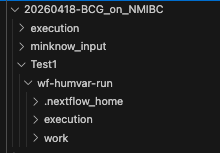

def humvar_run_dir = "${params.out_dir}/${params.sample}/wf-humvar-run"
is the only thing I changed.  

prep_for_getting_betas was killed  
methylcibersort container wasn't built properly

In [ ]:
# download to THE GREAT HALL

# in the great hall
cd /Users/lucy/mCS_docker
# rsync -a -e ssh aoraki:/weka/scratch/dejlu44p/conda-lock.yml .
docker build -f methylcibersort.dockerfile -t methylcibersort:latest .

# 1. First export to tarball  
docker save -o methylcibersort.tar methylcibersort:latest

# 2. copy tarball to aoraki  
rsync -av -e ssh methylcibersort.tar aoraki:/weka/scratch/dejlu44p/.

# 3. convert to sif image  
# in weka scratch
cd /weka/scratch/dejlu44p
tmux new -s buildmCS
srun --partition=aoraki --ntasks=1 --cpus-per-task=4 --mem=8G --time=4:00:00 --pty bash -i
apptainer build methylcibersort.sif docker-archive://methylcibersort.tar

# check function here
apptainer shell methylcibersort.sif
# still not working, go back to great hall
docker build -f methylcibersort.dockerfile -t methylcibersort:latest . --no-cache --progress=plain 2>&1 | tee build.log
# noticed these lines:
#11 68.46 To activate this environment, use:
#11 68.46
#11 68.46     micromamba activate mCS
#11 68.46
#11 68.46 Or to execute a single command in this environment, use:
#11 68.46
#11 68.46     micromamba run -n mCS mycommand
#11 68.46

grep -i "error\|failed\|warning" build.log

# 4. move to containers directory
mv /weka/scratch/dejlu44p/methylcibersort.sif /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/.

### Wed 29 April

checking that the new methylcibersort container is included

In [ ]:
mv /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/methylcibersort.sif /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/methylcibersort.old.sif

mv /weka/scratch/dejlu44p/methylcibersort.sif /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/.

In [ ]:
cd running_panorama
nextflow run ../wf-panorama \
    --clin_trial_mode \
    --project_name 20260418-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --cibersortx_username lucy.picard@postgrad.otago.ac.nz \
    --cibersortx_token 62c6ce7d617349ca44a7ee8efb7df65c  \
    -profile slurm,singularity \
    -resume

Still not running R.  
move it back to weka and transform it into a sandbox apptainer, then move the sandbox to /tmp to install things  

In [ ]:
mv /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/methylcibersort.sif /weka/scratch/dejlu44p/methylcibersort.sif
cd /weka/scratch/dejlu44p
apptainer build --sandbox methylcibersort.sandbox/ methylcibersort.sif
mv methylcibersort.sandbox /tmp/methylcibersort.sandbox
mv /home/dejlu44p/conda-lock.yml /tmp/.
cd /tmp
mkdir -p /tmp/methylcibersort.sandbox/home
ls -la /tmp/methylcibersort.sandbox/bin /tmp/methylcibersort.sandbox/usr/bin || true
apptainer shell --writable --no-home --containall --bind /tmp:/tmp --pwd /tmp methylcibersort.sandbox/
# apptainer shell --writable methylcibersort.sandbox

# apt-get update
# apt-get install -y python3-pip

# conda-lock install -n mCS /home/dejlu44p/conda-lock.yml

^ didn't work

Let's try making the container from scratch

In [ ]:
/projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/mCS_dev/methylcibersort.def

In [ ]:
Bootstrap: docker
From: ubuntu:22.04

%files
    mCS_venv_test.yaml /tmp/mCS_venv_test.yaml
    mCS_venv_test.yaml /opt/mCS_venv_test.yaml
    # conda-lock.yml /tmp/conda-lock.yml
    # conda-lock.yml /opt/conda-lock.yml
    MethylCIBERSORT_0.2.0.tar.gz /opt/MethylCIBERSORT_0.2.0.tar.gz

%post
    apt-get update && apt-get install -y \
        wget \
        curl \
        ca-certificates \
        build-essential \
        gfortran \
        git \
        bzip2 \
        libarchive-dev

    # Install Mambaforge
    curl -L https://github.com/conda-forge/mambaforge/releases/latest/download/Mambaforge-Linux-x86_64.sh -o /tmp/mambaforge.sh
    bash /tmp/mambaforge.sh -b -p /opt/mambaforge
    rm /tmp/mambaforge.sh
    
    # # Install micromamba
    # wget -qO- https://micromamba.snakepit.net/api/micromamba/linux-64/latest | tar -xvj -C /tmp/
    # mkdir -p /opt/micromamba/bin
    # mv /tmp/bin/micromamba /opt/micromamba/bin/
    
    # # Create environment from lock file
    # /opt/micromamba/bin/micromamba create -y --name mCS --file /tmp/conda-lock.yml
    
    # # Activate environment and install R package
    # /opt/micromamba/bin/micromamba run -n mCS R CMD INSTALL /opt/MethylCIBERSORT_0.2.0.tar.gz
    
    # # Cleanup
    # rm -rf /tmp/conda-lock.yml

# %environment
#     export PATH="/opt/micromamba/envs/mCS/bin:/opt/micromamba/bin:$PATH"
#     export CONDA_PREFIX="/opt/micromamba/envs/mCS"

%environment
    export PATH="/opt/mambaforge/bin:$PATH"

%runscript
    exec "$@"


In [ ]:
cd /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/mCS_dev

# move the mCS_dev directory to scratch and build there, to avoid issues with fakeroot and permissions and space
rsync -ar --info=progress2 /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/mCS_dev /weka/scratch/dejlu44p/.
cd /weka/scratch/dejlu44p/mCS_dev

APPTAINER_CACHEDIR=/weka/scratch/$USER/mCS_dev/apptainer_cache APPTAINER_TMPDIR=/weka/scratch/$USER/mCS_dev/apptainer_tmp apptainer build --sandbox methylcibersort.sandbox methylcibersort.def

# enter the sandbox
apptainer shell --writable methylcibersort.sandbox
apt-get update && apt-get install -y wget curl

# Error:
debconf: delaying package configuration, since apt-utils is not installed
dpkg: error: requested operation requires superuser privilege
E: Sub-process /usr/bin/dpkg returned an error code (2)

In [ ]:
# new methylcibersort def

Bootstrap: docker
From: ubuntu:22.04

%files
    mCS_venv_test.yaml /tmp/mCS_venv_test.yaml
    MethylCIBERSORT_0.2.0.tar.gz /opt/MethylCIBERSORT_0.2.0.tar.gz

%post
    apt-get update && apt-get install -y \
        wget \
        curl \
        ca-certificates \
        build-essential \
        gfortran \
        git \
        bzip2 \
        libarchive-dev

    # Install Mambaforge
    curl -L https://github.com/conda-forge/mambaforge/releases/latest/download/Mambaforge-Linux-x86_64.sh -o /tmp/mambaforge.sh
    bash /tmp/mambaforge.sh -b -p /opt/mambaforge
    rm /tmp/mambaforge.sh

%environment
    export PATH="/opt/mambaforge/bin:$PATH"

%runscript
    exec "$@"


In [ ]:
APPTAINER_CACHEDIR=/weka/scratch/$USER/mCS_dev/apptainer_cache APPTAINER_TMPDIR=/weka/scratch/$USER/mCS_dev/apptainer_tmp  apptainer build --sandbox methylcibersort.sandbox methylcibersort.def

Try rebuilding using docker and great hall



In [ ]:
# in the great hall
cd /Users/lucy/mCS_docker
# rsync -a -e ssh aoraki:/weka/scratch/dejlu44p/conda-lock.yml .
docker build -f methylcibersort.dockerfile -t methylcibersort:latest .

In [ ]:
# 1. First, update the package manager and install dependencies
apt-get update && apt-get install -y \
    curl \
    bzip2 \
    libarchive-dev

# 2. Download and install Mambaforge (lightweight mamba distribution)
# This is smaller than Miniconda + mamba
curl -L https://github.com/conda-forge/mambaforge/releases/latest/download/Mambaforge-Linux-x86_64.sh -o /tmp/mambaforge.sh

# 3. Install Mambaforge to a location (e.g., /opt/mambaforge)
bash /tmp/mambaforge.sh -b -p /opt/mambaforge

# 4. Initialize mamba
/opt/mambaforge/bin/conda init bash

# 5. Add mamba to PATH
export PATH="/opt/mambaforge/bin:$PATH"

# 6. Verify installation
mamba --version
conda --version

# 7. (Optional) Clean up installer
rm /tmp/mambaforge.sh

That wasn't working, trying to rebuild using a container that already has mamba installed, and use the normal yaml file to build rather than conda-lock

In [ ]:
Bootstrap: docker
From: mambaorg/micromamba:latest

%files
    mCS_venv_test.yaml /opt/mCS_venv_test.yaml
    conda-lock.yml /opt/conda-lock.yml
    MethylCIBERSORT_0.2.0.tar.gz /opt/MethylCIBERSORT_0.2.0.tar.gz

%post
    apt-get update && apt-get install -y \
        build-essential \
        gfortran \
        git \
        bzip2 \
        libarchive-dev
    
    # Initialize shell for micromamba
    eval "$(micromamba shell-init -s bash)"

    # Install into base env from lock-file
    # micromamba install --yes --file /opt/conda-lock.yml
    micromamba create --file /opt/mCS_venv_test.yaml

    # Activate environment and install R package
    micromamba run -n mCS R CMD INSTALL /opt/MethylCIBERSORT_0.2.0.tar.gz

    micromamba clean --all --yes

%environment
    eval "$(micromamba shell hook --shell )"
    micromamba activate mCS
    
%runscript
    exec "$@"


In [ ]:
# mcS.yaml
name: mCS
channels:
  - conda-forge
  - bioconda
  - defaults
channel_priority: strict
dependencies:
  - bioconductor-minfi=1.32.0
  - r-base=3.6.3
  - r-caret=6.0_88
  - r-glmnet=4.1_1
  - r-doparallel=1.0.16
  - r-nmf=0.21.0


def file that worked!

In [ ]:
Bootstrap: docker
From: mambaorg/micromamba:latest

%files
    mCS_venv_test.yaml /opt/mCS_venv_test.yaml
    conda-lock.yml /opt/conda-lock.yml
    MethylCIBERSORT_0.2.0.tar.gz /opt/MethylCIBERSORT_0.2.0.tar.gz

%post
    apt-get update && apt-get install -y \
        build-essential \
        gfortran \
        git \
        bzip2 \
        libarchive-dev \
        procps       
        # ^ adds 'ps', required by Nextflow
    
    # Initialize shell for micromamba
    eval "$(micromamba shell-init -s bash)"

    # Install into base env from lock-file
    # micromamba install --yes --file /opt/conda-lock.yml
    micromamba create --file /opt/mCS_venv_test.yaml

    # Activate environment and install R package
    micromamba run -n mCS R CMD INSTALL /opt/MethylCIBERSORT_0.2.0.tar.gz

    micromamba clean --all --yes

%environment
    export MAMBA_ROOT_PREFIX=/opt/conda
    export MAMBA_EXE=/usr/local/bin/micromamba
    export XDG_CACHE_HOME=/tmp
    
%runscript
    exec "$@"


In [ ]:
cd /weka/scratch/dejlu44p/mCS_dev
APPTAINER_CACHEDIR=/weka/scratch/$USER/mCS_dev/apptainer_cache APPTAINER_TMPDIR=/weka/scratch/$USER/mCS_dev/apptainer_tmp  apptainer build --sandbox methylcibersort.sandbox methylcibersort.def
rsync -ar --info=progress2 /weka/scratch/dejlu44p/mCS_dev/methylcibersort.sandbox /projects/uow/GERL/dejlu879/Panorama/wf-panorama/containers/.

cd /projects/uow/GERL/dejlu879/Panorama/running_panorama
nextflow run ../wf-panorama \
    --clin_trial_mode \
    --project_name 20260418-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --cibersortx_username lucy.picard@postgrad.otago.ac.nz \
    --cibersortx_token 62c6ce7d617349ca44a7ee8efb7df65c  \
    -profile slurm,singularity \
    -resume

wooooo it ran the container!

### Mon 4 May 2026

Whew I'm running very behind where I wanted to be at this point   
Just added meth_coverage_threshold as the defaults all the way in the python script was 0 at the moment. Set it to 30.  
New command to run includes this parameter

In [ ]:
cd /projects/uow/GERL/dejlu879/Panorama/running_panorama
nextflow run ../wf-panorama \
    --clin_trial_mode \
    --project_name 20260418-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --meth_coverage_threshold 5 \
    --cibersortx_username lucy.picard@postgrad.otago.ac.nz \
    --cibersortx_token 62c6ce7d617349ca44a7ee8efb7df65c  \
    -profile slurm,singularity \
    -resume

/home/dejlu44p/.conda/envs/gen_venv/bin/python3

In [ ]:
python3 /projects/uow/GERL/dejlu879/Panorama/wf-panorama/bin/process_result_before_betas.py --epic IlluminaEPIC_genomic_locations_hg38.csv --dss Test1.wf_mods.all.dss_format.tsv --depth 5 --out Test1.pre_beta.csv

# it failed on the CIBERSORTx step - expected as the token has expired.  

Updated the reference used for panel prep to draw from MethylCIBERSORT rather than the ref_atlas_bladder.csv I had last used for testing  


Make apptainers concrete sif rather than sandbox


In [ ]:
srun --partition=aoraki --ntasks=1 --cpus-per-task=4 --mem=8G --time=4:00:00 --pty bash -i

apptainer build methylcibersort.sif methylcibersort.sandbox/
apptainer build general.sif general.sandbox/

### Tue 5 May 2026  

rerun panel_prep section as I have updated the deconvolution reference files


In [ ]:
cd /projects/uow/GERL/dejlu879/Panorama/running_panorama
module load nextflow

nextflow run ../wf-panorama \
    --make_target_bed \
    --project_name 20260505-BCG_on_NMIBC \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --mCS_cancer_type bladder \
    -profile slurm,singularity \
    -resume

While that's running, see if I can fake the Cibersort section already being run so I can continue debugging

In [ ]:
# copied old cibersort file here: 
/projects/uow/GERL/dejlu879/Panorama/running_panorama/20260418-BCG_on_NMIBC/Test1/methylCS/CIBERSORTx_Test1_Results.csv

In [ ]:
nextflow run ../wf-panorama \
    --clin_trial_mode \
    --project_name 20260418-BCG_on_NMIBC \
    --sample Test1 \
    --bam_directory /projects/uow/GERL/dejlu879/data/Panorama/all_passed_bams \
    --panel_metadata ../wf-panorama/demo_input/panel_metadata.csv \
    --meth_coverage_threshold 5 \
    --cibersortx_username placeholder \
    --cibersortx_token placeholder \
    --skip_cibersortx \
    -profile slurm,singularity \
    -resume

Note that after changing the infiltrate reference dataset from meth_atlas to mCS, the amount of genome coverage reduced significantly (to < 0.5%).  BE AWARE of this during testing. Consider doing WGS on tumours instead.  
Changed the default buffersize to 10kb and got 0.71%.  
